# Black–Scholes Option Pricing with PINNs, ANNs, FDM, and Monte Carlo

This notebook implements and compares four approaches for pricing a European call option under the Black–Scholes model:

1. **Exact analytical solution**  
2. **Classical numerical methods**  
   - Finite Difference Method (FDM)  
   - Monte Carlo Simulation (MCS)  
3. **Data-driven Artificial Neural Network (ANN)**  
4. **Physics-Informed Neural Network (PINN)**  

We evaluate and compare these methods in terms of:

- **Accuracy** (error vs exact Black–Scholes price)  
- **Computational cost** (proxy: runtime and number of samples/paths)  
- **Scalability and adaptability**  

The implementation is designed for environments like Google Colab, using `scipy.special.erf` for the normal CDF and SciPy sparse solvers for FDM.


## 1. Imports and Global Configuration

In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from scipy.special import erf  # for normal CDF
import scipy.sparse as sp
import scipy.sparse.linalg as spla

# For reproducibility
np.random.seed(42)
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 2. Black–Scholes Model and Exact Solution

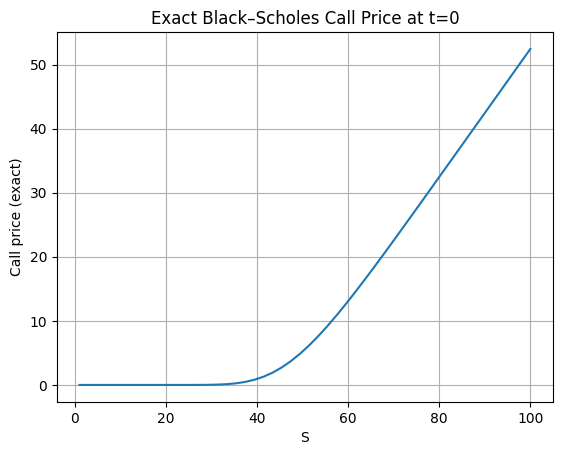

In [2]:
# Parameters
r = 0.05      # risk-free rate
sigma = 0.2   # volatility
K = 50.0      # strike
T = 1.0       # maturity (in years)

def norm_cdf(x):
    """Vectorized standard normal CDF using scipy.special.erf."""
    return 0.5 * (1.0 + erf(x / np.sqrt(2.0)))

def bs_call_price(S, t=0.0, r=r, sigma=sigma, K=K, T=T):
    """
    Closed-form Black–Scholes price for a European call.
    S: underlying price (scalar or numpy array)
    t: current time
    """
    S = np.array(S, dtype=float)
    tau = np.maximum(T - t, 1e-10)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    return S * norm_cdf(d1) - K * np.exp(-r * tau) * norm_cdf(d2)

# Quick test on a grid
S_grid = np.linspace(1, 100, 50)
V_exact_grid = bs_call_price(S_grid, t=0.0)
plt.figure()
plt.plot(S_grid, V_exact_grid)
plt.xlabel("S")
plt.ylabel("Call price (exact)")
plt.title("Exact Black–Scholes Call Price at t=0")
plt.grid(True)
plt.show()

## 3. Finite Difference Method (FDM) for Black–Scholes

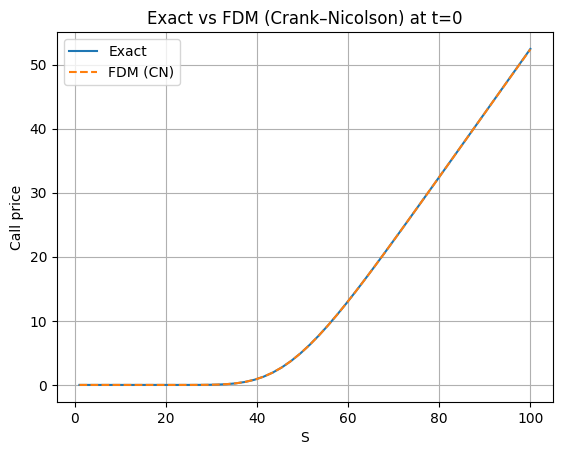

In [3]:

def crank_nicolson_call(S_max=200, M=200, N=200, r=r, sigma=sigma, K=K, T=T):
    """
    Crank-Nicolson finite difference method for European call
    """
    # Grid
    dS = S_max / M
    dt = T / N
    S = np.linspace(0, S_max, M+1)

    # Terminal condition
    V = np.maximum(S - K, 0.0)

    # Coefficients for internal points (i=1 to M-1)
    alpha = np.zeros(M+1)
    beta = np.zeros(M+1)
    gamma = np.zeros(M+1)

    for i in range(1, M):
        alpha[i] = 0.25 * dt * (sigma**2 * i**2 - r * i)
        beta[i] = -0.5 * dt * (sigma**2 * i**2 + r)
        gamma[i] = 0.25 * dt * (sigma**2 * i**2 + r * i)

    # Time stepping (backward)
    for n in range(N-1, -1, -1):
        t = n * dt

        # Boundary conditions
        V[0] = 0.0  # S=0
        V[M] = S_max - K * np.exp(-r * (T - t))  # S=S_max

        # Solve tridiagonal system for internal points
        # Construction des matrices A et B
        A = np.zeros((M-1, M-1))
        B = np.zeros((M-1, M-1))
        rhs = np.zeros(M-1)

        for i in range(1, M):
            j = i - 1  # index in matrix

            # Matrix A
            if i > 1:
                A[j, j-1] = -alpha[i]
            A[j, j] = 1 - beta[i]
            if i < M-1:
                A[j, j+1] = -gamma[i]

            # Matrix B
            if i > 1:
                B[j, j-1] = alpha[i]
            B[j, j] = 1 + beta[i]
            if i < M-1:
                B[j, j+1] = gamma[i]

        # Right-hand side
        rhs = B @ V[1:M]

        # Apply boundary conditions to rhs
        rhs[0] += alpha[1] * V[0]
        rhs[-1] += gamma[M-1] * V[M]

        # Solve system
        V[1:M] = np.linalg.solve(A, rhs)

    return S, V

# Run FDM once and compare with exact on t=0
S_fd, V_fd = crank_nicolson_call(S_max=200, M=200, N=200)
S_eval = np.linspace(1, 100, 50)
V_fd_interp = np.interp(S_eval, S_fd, V_fd)
V_ex = bs_call_price(S_eval, t=0.0)

plt.figure()
plt.plot(S_eval, V_ex, label="Exact")
plt.plot(S_eval, V_fd_interp, linestyle="--", label="FDM (CN)")
plt.xlabel("S")
plt.ylabel("Call price")
plt.legend()
plt.grid(True)
plt.title("Exact vs FDM (Crank–Nicolson) at t=0")
plt.show()

## 4. Monte Carlo Simulation (MCS)

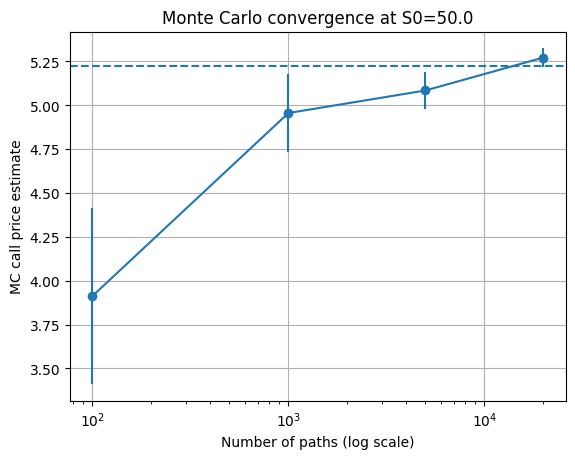

Exact Black–Scholes price at S0=50: 5.225291786092782


In [4]:
def mc_call_price(S0, N_paths=10000, r=r, sigma=sigma, K=K, T=T, seed=42):
    """Monte Carlo estimator for European call under Black–Scholes."""
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(N_paths)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0.0)
    disc_payoff = np.exp(-r * T) * payoff
    return disc_payoff.mean(), disc_payoff.std() / np.sqrt(N_paths)

# Example: convergence vs number of paths
S0 = 50.0
N_list = [100, 1000, 5000, 20000]
mc_estimates = []
mc_std_err = []

for N in N_list:
    est, se = mc_call_price(S0, N_paths=N)
    mc_estimates.append(est)
    mc_std_err.append(se)

exact_S0 = bs_call_price(S0, t=0.0)
plt.figure()
plt.errorbar(N_list, mc_estimates, yerr=mc_std_err, fmt="o-")
plt.axhline(exact_S0, linestyle="--")
plt.xscale("log")
plt.xlabel("Number of paths (log scale)")
plt.ylabel("MC call price estimate")
plt.title(f"Monte Carlo convergence at S0={S0}")
plt.grid(True)
plt.show()

print("Exact Black–Scholes price at S0=50:", exact_S0)

## 5. Data-Driven ANN Approximation of Black–Scholes Price

We now train a standard feedforward neural network (ANN) to approximate the mapping

\( S \mapsto C(S,t=0) \)

using synthetic data generated from the exact Black–Scholes formula. We vary the training sample size:

- 5 points  
- 50 points  
- 100 points  

and compare:

- Exact solution  
- ANN predictions  
- Monte Carlo estimates (for reference, at selected points)

This illustrates the effect of sample size on ANN stability and accuracy.


Training ANN with sample size N=5
Training ANN with sample size N=50
Training ANN with sample size N=100


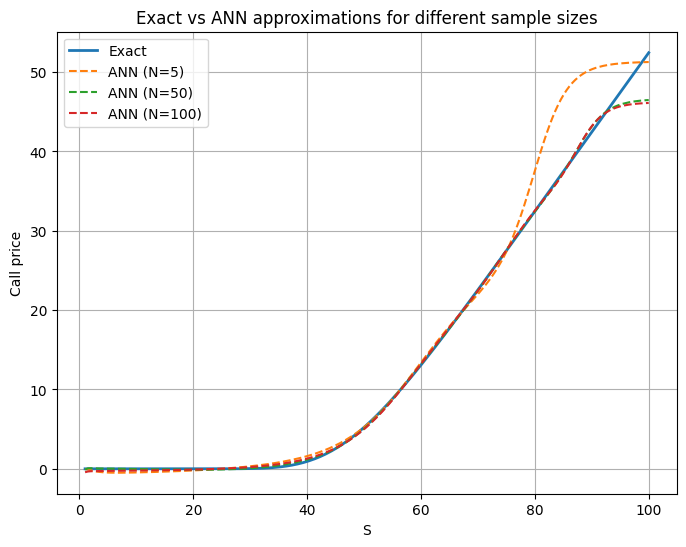

In [5]:
class SimpleANN(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=32, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, x):
        return self.net(x)

def train_ann(sample_size=50, epochs=2000, lr=1e-3, verbose=False):
    # Generate training data
    S_train = np.linspace(1, 100, sample_size)
    y_train = bs_call_price(S_train, t=0.0)
    S_train_t = torch.tensor(S_train, dtype=torch.float32).view(-1,1).to(device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1,1).to(device)

    model = SimpleANN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(S_train_t)
        loss = loss_fn(pred, y_train_t)
        loss.backward()
        optimizer.step()
        if verbose and epoch % 500 == 0:
            print(f"[ANN][N={sample_size}] Epoch {epoch}, loss={loss.item():.4e}")
    return model

# Train ANNs with different sample sizes
sample_sizes = [5, 50, 100]
ann_models = {}
for N in sample_sizes:
    print(f"Training ANN with sample size N={N}")
    ann_models[N] = train_ann(sample_size=N, epochs=3000, lr=1e-3, verbose=False)

# Evaluation grid
S_test = np.linspace(1, 100, 200)
V_exact_test = bs_call_price(S_test, t=0.0)

plt.figure(figsize=(8,6))
plt.plot(S_test, V_exact_test, label="Exact", linewidth=2)

for N in sample_sizes:
    model = ann_models[N]
    with torch.no_grad():
        S_tensor = torch.tensor(S_test, dtype=torch.float32).view(-1,1).to(device)
        V_ann = model(S_tensor).cpu().numpy().flatten()
    plt.plot(S_test, V_ann, label=f"ANN (N={N})", linestyle="--")

plt.xlabel("S")
plt.ylabel("Call price")
plt.title("Exact vs ANN approximations for different sample sizes")
plt.legend()
plt.grid(True)
plt.show()

### 5.1 ANN vs Monte Carlo at Selected Points

In [6]:
# Compare ANN vs MC vs Exact at a few S points
S_points = [20, 50, 80]
N_paths_for_mc = 20000

print("Comparison table: S, Exact, ANN(N=5), ANN(N=50), ANN(N=100), MC estimate")

for S0 in S_points:
    exact_val = bs_call_price(S0, t=0.0)
    # ANN predictions
    ann_preds = {}
    for N in sample_sizes:
        model = ann_models[N]
        with torch.no_grad():
            inp = torch.tensor([[S0]], dtype=torch.float32).to(device)
            ann_preds[N] = model(inp).item()

    # MC estimate
    mc_est, mc_se = mc_call_price(S0, N_paths=N_paths_for_mc)
    print(f"S={S0:5.1f} | Exact={exact_val:8.4f} | " +
          f"ANN5={ann_preds[5]:8.4f} | ANN50={ann_preds[50]:8.4f} | " +
          f"ANN100={ann_preds[100]:8.4f} | MC={mc_est:8.4f} (+/-{mc_se:.4f})")

Comparison table: S, Exact, ANN(N=5), ANN(N=50), ANN(N=100), MC estimate
S= 20.0 | Exact=  0.0000 | ANN5= -0.2066 | ANN50= -0.1122 | ANN100= -0.1011 | MC=  0.0000 (+/-0.0000)
S= 50.0 | Exact=  5.2253 | ANN5=  5.2451 | ANN50=  5.0457 | ANN100=  4.9939 | MC=  5.2723 (+/-0.0526)
S= 80.0 | Exact= 32.4565 | ANN5= 37.5660 | ANN50= 32.4192 | ANN100= 32.5384 | MC= 32.5540 (+/-0.1147)


## 6. Physics-Informed Neural Network (PINN) for Black–Scholes

We now implement a PINN that learns the solution \( V(S,t) \) of the Black–Scholes PDE by minimizing a composite loss:

- PDE residual loss (interior points)  
- Terminal condition loss (at \(t=T\))  
- Boundary condition loss (at \(S=0\) and large \(S\))  

This is a full spatio-temporal model, not only a static fit at \(t=0\). For runtime reasons, default hyperparameters are modest; you may increase the number of collocation points and epochs for higher accuracy.


In [7]:
class PINN_BSM(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.layers = nn.ModuleList(
            [nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1)]
        )
    def forward(self, x):
        # x: [S, t]
        for layer in self.layers[:-1]:
            x = torch.tanh(layer(x))
        return self.layers[-1](x)

def pinn_bs_residual(model, S, t, r=r, sigma=sigma):
    inp = torch.cat((S, t), dim=1)  # [N, 2]
    V = model(inp)
    # First derivatives
    dV = torch.autograd.grad(V, inp, torch.ones_like(V), create_graph=True)[0]
    V_S = dV[:, 0:1]
    V_t = dV[:, 1:2]
    # Second derivative wrt S
    d2V = torch.autograd.grad(V_S, inp, torch.ones_like(V_S), create_graph=True)[0]
    V_SS = d2V[:, 0:1]
    # BS PDE residual
    return V_t + 0.5 * sigma**2 * S**2 * V_SS + r * S * V_S - r * V

def sample_pinn_points(N_f=2000, N_bc=200, N_ic=200, S_max=100.0):
    # Interior collocation points
    S_f = torch.rand(N_f, 1) * S_max
    t_f = torch.rand(N_f, 1) * T

    # Terminal (t = T)
    S_ic = torch.rand(N_ic, 1) * S_max
    t_ic = torch.ones_like(S_ic) * T

    # Boundary S=0 and S=S_max
    t_bc = torch.rand(N_bc, 1) * T
    S_bc0 = torch.zeros_like(t_bc)
    S_bcM = torch.ones_like(t_bc) * S_max

    return (S_f, t_f, S_ic, t_ic, S_bc0, S_bcM, t_bc)

[PINN] Epoch 0, loss=7.6470e+03
[PINN] Epoch 200, loss=2.5210e+03
[PINN] Epoch 400, loss=1.0203e+03
[PINN] Epoch 600, loss=4.4154e+02
[PINN] Epoch 800, loss=2.1959e+02
[PINN] Epoch 1000, loss=1.1064e+02
[PINN] Epoch 1200, loss=5.9577e+01
[PINN] Epoch 1400, loss=3.8586e+01
[PINN] Epoch 1600, loss=2.3954e+01
[PINN] Epoch 1800, loss=1.7860e+01


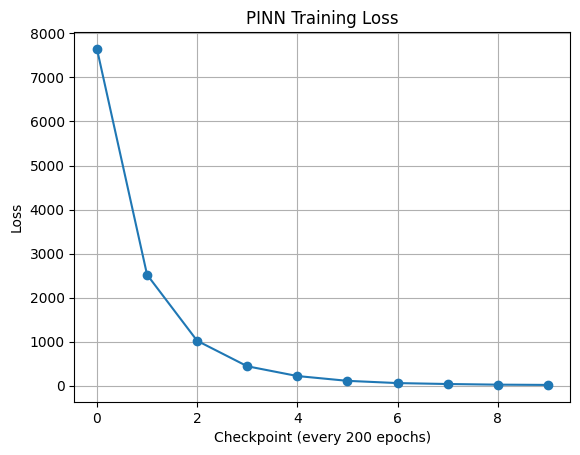

In [8]:
# Build and train PINN (this may take some time for large N/epochs)
layers = [2, 64, 64, 64, 1]
pinn_model = PINN_BSM(layers).to(device)
optimizer = optim.Adam(pinn_model.parameters(), lr=1e-3)

N_f, N_bc, N_ic = 2000, 200, 200
S_max = 100.0

loss_history = []

for epoch in range(2000):
    pinn_model.train()
    optimizer.zero_grad()

    S_f, t_f, S_ic, t_ic, S_bc0, S_bcM, t_bc = sample_pinn_points(
        N_f=N_f, N_bc=N_bc, N_ic=N_ic, S_max=S_max
    )

    S_f = S_f.to(device); t_f = t_f.to(device)
    S_ic = S_ic.to(device); t_ic = t_ic.to(device)
    S_bc0 = S_bc0.to(device); S_bcM = S_bcM.to(device); t_bc = t_bc.to(device)

    # Enable gradients
    S_f.requires_grad_(True)
    t_f.requires_grad_(True)

    # PDE residual
    f_res = pinn_bs_residual(pinn_model, S_f, t_f)
    loss_f = torch.mean(f_res**2)

    # Terminal condition
    V_ic = pinn_model(torch.cat((S_ic, t_ic), dim=1))
    payoff = torch.clamp(S_ic - K, min=0.0)
    loss_ic = torch.mean((V_ic - payoff)**2)

    # Boundary S=0: V=0
    V_bc0 = pinn_model(torch.cat((S_bc0, t_bc), dim=1))
    loss_bc0 = torch.mean(V_bc0**2)

    # Boundary S=S_max: V ~ S_max - K*exp(-r*(T-t))
    V_bcM = pinn_model(torch.cat((S_bcM, t_bc), dim=1))
    target_bcM = S_bcM - K * torch.exp(-r * (T - t_bc))
    loss_bcM = torch.mean((V_bcM - target_bcM)**2)

    loss = loss_f + 10.0 * loss_ic + loss_bc0 + loss_bcM

    loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        loss_history.append(loss.item())
        print(f"[PINN] Epoch {epoch}, loss={loss.item():.4e}")

plt.figure()
plt.plot(loss_history, marker="o")
plt.xlabel("Checkpoint (every 200 epochs)")
plt.ylabel("Loss")
plt.title("PINN Training Loss")
plt.grid(True)
plt.show()

### 6.1 PINN vs Exact and FDM at t = 0

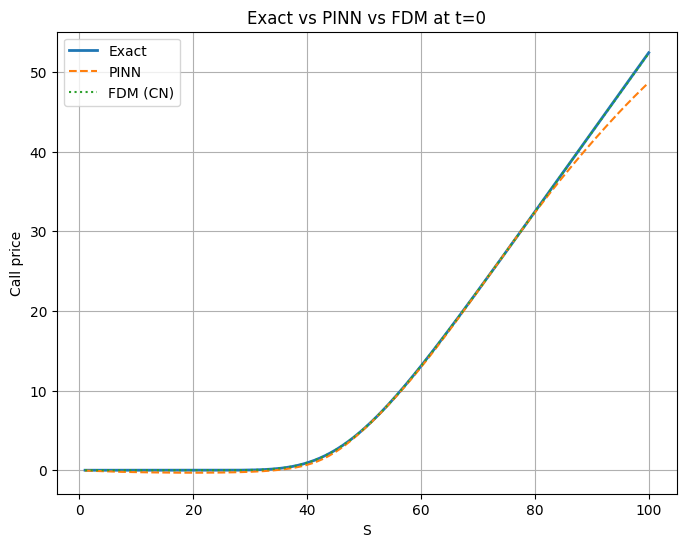

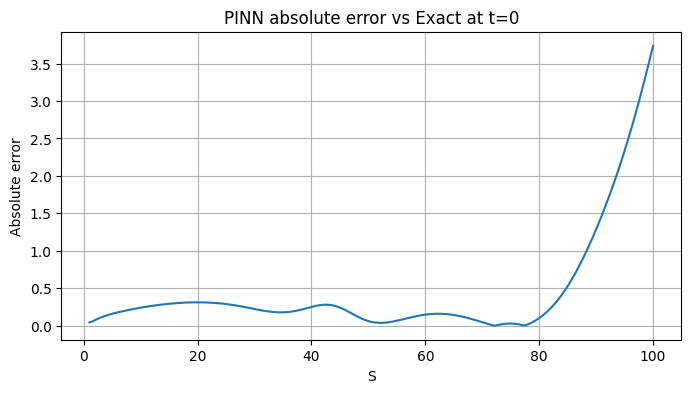

In [9]:
# Evaluate PINN for t=0 on a grid and compare
S_eval = np.linspace(1, 100, 200)
S_eval_torch = torch.tensor(S_eval, dtype=torch.float32).view(-1,1).to(device)
t0_torch = torch.zeros_like(S_eval_torch).to(device)

pinn_model.eval()
with torch.no_grad():
    V_pinn = pinn_model(torch.cat((S_eval_torch, t0_torch), dim=1)).cpu().numpy().flatten()

V_exact_eval = bs_call_price(S_eval, t=0.0)

plt.figure(figsize=(8,6))
plt.plot(S_eval, V_exact_eval, label="Exact", linewidth=2)
plt.plot(S_eval, V_pinn, label="PINN", linestyle="--")
S_fd, V_fd = crank_nicolson_call(S_max=200, M=200, N=200)
V_fd_interp = np.interp(S_eval, S_fd, V_fd)
plt.plot(S_eval, V_fd_interp, label="FDM (CN)", linestyle=":")

plt.xlabel("S")
plt.ylabel("Call price")
plt.title("Exact vs PINN vs FDM at t=0")
plt.legend()
plt.grid(True)
plt.show()

# Plot pointwise absolute error for PINN
plt.figure(figsize=(8,4))
plt.plot(S_eval, np.abs(V_pinn - V_exact_eval))
plt.xlabel("S")
plt.ylabel("Absolute error")
plt.title("PINN absolute error vs Exact at t=0")
plt.grid(True)
plt.show()


=== Entraînement PINN avec 1000 points de collocation ===
RMSE pour 1000 points: 0.872751

=== Entraînement PINN avec 2000 points de collocation ===
RMSE pour 2000 points: 0.483833

=== Entraînement PINN avec 5000 points de collocation ===
RMSE pour 5000 points: 0.177397


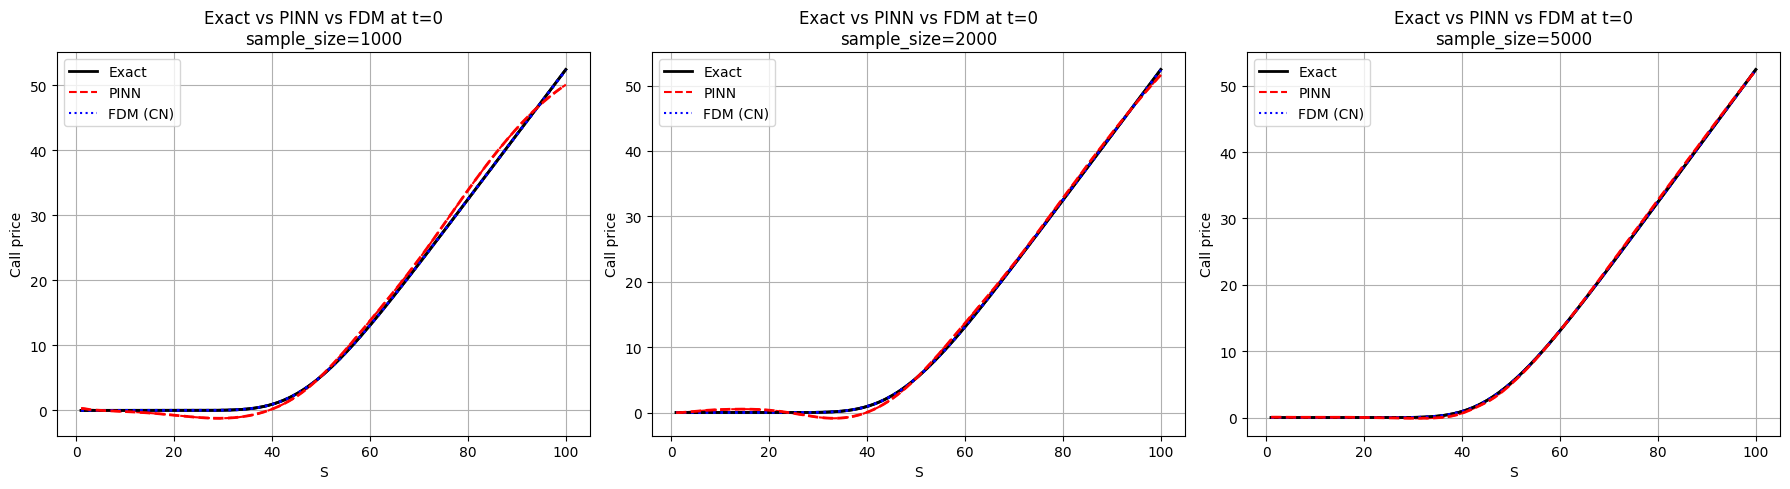

In [10]:
# Test avec différentes tailles d'échantillons pour le PINN
sample_sizes = [1000, 2000, 5000]  # Points de collocation
epochs_list = [2000, 3000, 5000]    # Époques correspondantes

# Définir S_eval une seule fois pour toutes les évaluations
S_eval = np.linspace(1, 100, 200)
S_eval_torch = torch.tensor(S_eval, dtype=torch.float32).view(-1,1).to(device)
t0_torch = torch.zeros_like(S_eval_torch).to(device)
V_exact_eval = bs_call_price(S_eval, t=0.0)

# Obtenir FDM corrigé une seule fois
S_fd_corrected, V_fd_corrected = crank_nicolson_call(S_max=200, M=200, N=200)
V_fd_corrected_interp = np.interp(S_eval, S_fd_corrected, V_fd_corrected)

# Créer UNE SEULE FIGURE avec 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (n_points, epochs) in enumerate(zip(sample_sizes, epochs_list)):
    print(f"\n=== Entraînement PINN avec {n_points} points de collocation ===")

    # Réinitialiser le modèle
    pinn_model = PINN_BSM(layers).to(device)
    optimizer = optim.Adam(pinn_model.parameters(), lr=1e-3)

    # Entraînement
    for epoch in range(epochs):
        pinn_model.train()
        optimizer.zero_grad()

        S_f, t_f, S_ic, t_ic, S_bc0, S_bcM, t_bc = sample_pinn_points(
            N_f=n_points, N_bc=200, N_ic=200, S_max=100.0
        )

        # Transférer sur device et activer gradients
        S_f = S_f.to(device); t_f = t_f.to(device)
        S_ic = S_ic.to(device); t_ic = t_ic.to(device)
        S_bc0 = S_bc0.to(device); S_bcM = S_bcM.to(device); t_bc = t_bc.to(device)
        S_f.requires_grad_(True)
        t_f.requires_grad_(True)

        # Calcul des losses
        f_res = pinn_bs_residual(pinn_model, S_f, t_f)
        loss_f = torch.mean(f_res**2)

        V_ic = pinn_model(torch.cat((S_ic, t_ic), dim=1))
        payoff = torch.clamp(S_ic - K, min=0.0)
        loss_ic = torch.mean((V_ic - payoff)**2)

        V_bc0 = pinn_model(torch.cat((S_bc0, t_bc), dim=1))
        loss_bc0 = torch.mean(V_bc0**2)

        V_bcM = pinn_model(torch.cat((S_bcM, t_bc), dim=1))
        target_bcM = S_bcM - K * torch.exp(-r * (T - t_bc))
        loss_bcM = torch.mean((V_bcM - target_bcM)**2)

        loss = loss_f + 50.0 * loss_ic + 10.0 * loss_bc0 + 10.0 * loss_bcM
        loss.backward()
        optimizer.step()

    # Évaluation
    pinn_model.eval()
    with torch.no_grad():
        V_pinn = pinn_model(torch.cat((S_eval_torch, t0_torch), dim=1)).cpu().numpy().flatten()

    rmse_pinn = np.sqrt(np.mean((V_pinn - V_exact_eval)**2))
    print(f"RMSE pour {n_points} points: {rmse_pinn:.6f}")

    # UN SEUL GRAPHIQUE par sample size
    ax = axes[i]
    ax.plot(S_eval, V_exact_eval, label="Exact", linewidth=2, color='black')
    ax.plot(S_eval, V_pinn, label="PINN", linestyle="--", color='red')
    ax.plot(S_eval, V_fd_corrected_interp, label="FDM (CN)", linestyle=":", color='blue')
    ax.set_xlabel("S")
    ax.set_ylabel("Call price")
    ax.set_title(f"Exact vs PINN vs FDM at t=0\nsample_size={n_points}")
    ax.legend()
    ax.grid(True)
    ax.plot(S_eval, V_exact_eval, label='Solution Exacte', linewidth=2, color='black')
    ax.plot(S_eval, V_fd_corrected_interp, label='FDM', linestyle=':', linewidth=2, color='blue')
    ax.plot(S_eval, V_pinn, label=f'PINN', linestyle='--', linewidth=2, color='red')
    ax.set

plt.tight_layout()
plt.show()


=== Entraînement PINN avec 1000 points de collocation ===
RMSE pour 1000 points: 0.903980

=== Entraînement PINN avec 2000 points de collocation ===
RMSE pour 2000 points: 0.489187

=== Entraînement PINN avec 5000 points de collocation ===
RMSE pour 5000 points: 0.199439

\begin{table}[htbp]
\centering
\caption{Performance metrics of PINN compared to Exact and FDM solutions}
\label{tab:pinn_fdm_metrics}
\renewcommand{\arraystretch}{1.2}
\resizebox{\textwidth}{!}{
\begin{tabular}{c|ccc|ccc}
\hline
\multirow{2}{*}{Sample Size} & \multicolumn{3}{c|}{PINN vs Exact} & \multicolumn{3}{c}{PINN vs FDM} \\
\cline{2-7}
& MAE & MSE & RMSE & MAE & MSE & RMSE \\
\hline
1000 & 0.793305 & 0.817180 & 0.903980 & 0.791722 & 0.811891 & 0.901050 \\
2000 & 0.444889 & 0.239304 & 0.489187 & 0.444762 & 0.239143 & 0.489022 \\
5000 & 0.153325 & 0.039776 & 0.199439 & 0.150077 & 0.038208 & 0.195469 \\
\hline
\end{tabular}}
}
\end{table}


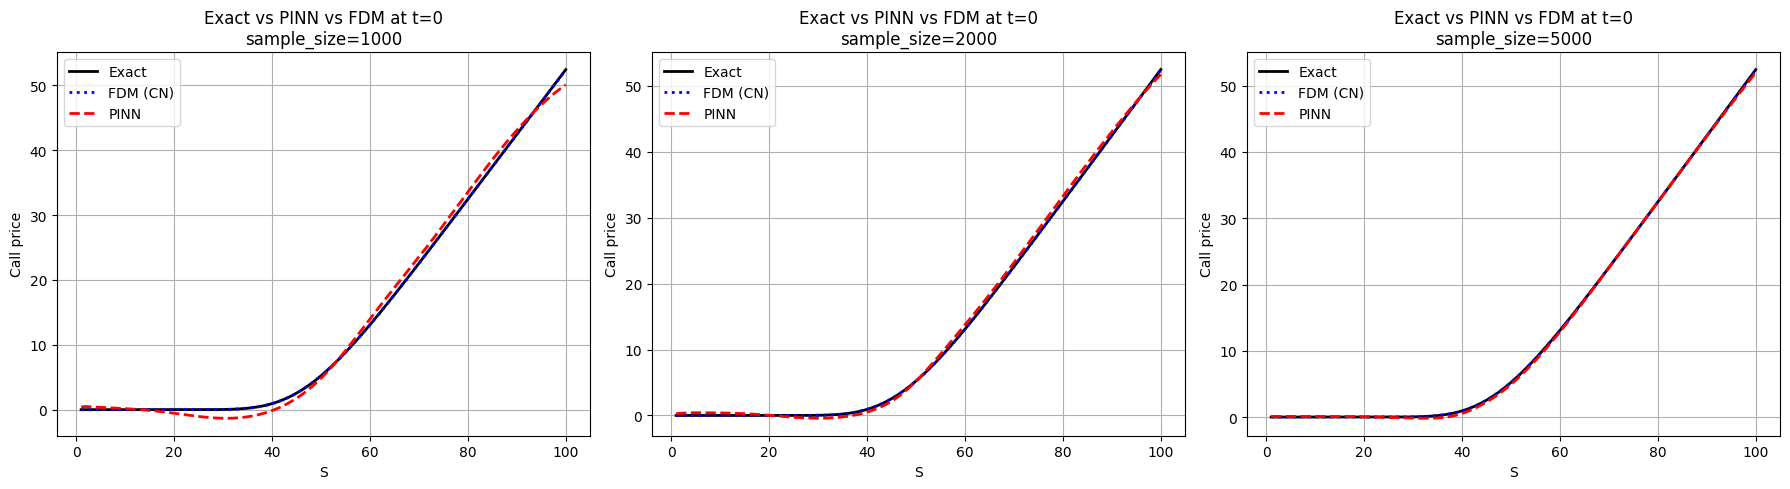

In [11]:
# Test avec différentes tailles d'échantillons pour le PINN
sample_sizes = [1000, 2000, 5000]  # Points de collocation
epochs_list = [2000, 3000, 5000]    # Époques correspondantes

# Définir S_eval une seule fois pour toutes les évaluations
S_eval = np.linspace(1, 100, 200)
S_eval_torch = torch.tensor(S_eval, dtype=torch.float32).view(-1, 1).to(device)
t0_torch = torch.zeros_like(S_eval_torch).to(device)
V_exact_eval = bs_call_price(S_eval, t=0.0)

# Obtenir FDM corrigé une seule fois
S_fd_corrected, V_fd_corrected = crank_nicolson_call(S_max=200, M=200, N=200)
V_fd_corrected_interp = np.interp(S_eval, S_fd_corrected, V_fd_corrected)

# Créer UNE SEULE FIGURE avec 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Liste pour stocker les métriques
metrics = []

for i, (n_points, epochs) in enumerate(zip(sample_sizes, epochs_list)):
    print(f"\n=== Entraînement PINN avec {n_points} points de collocation ===")

    # Réinitialiser le modèle
    pinn_model = PINN_BSM(layers).to(device)
    optimizer = optim.Adam(pinn_model.parameters(), lr=1e-3)

    # Entraînement
    for epoch in range(epochs):
        pinn_model.train()
        optimizer.zero_grad()

        S_f, t_f, S_ic, t_ic, S_bc0, S_bcM, t_bc = sample_pinn_points(
            N_f=n_points, N_bc=200, N_ic=200, S_max=100.0
        )

        # Transférer sur device
        S_f = S_f.to(device); t_f = t_f.to(device)
        S_ic = S_ic.to(device); t_ic = t_ic.to(device)
        S_bc0 = S_bc0.to(device); S_bcM = S_bcM.to(device); t_bc = t_bc.to(device)

        S_f.requires_grad_(True)
        t_f.requires_grad_(True)

        # Calcul des losses
        f_res = pinn_bs_residual(pinn_model, S_f, t_f)
        loss_f = torch.mean(f_res**2)

        V_ic = pinn_model(torch.cat((S_ic, t_ic), dim=1))
        payoff = torch.clamp(S_ic - K, min=0.0)
        loss_ic = torch.mean((V_ic - payoff)**2)

        V_bc0 = pinn_model(torch.cat((S_bc0, t_bc), dim=1))
        loss_bc0 = torch.mean(V_bc0**2)

        V_bcM = pinn_model(torch.cat((S_bcM, t_bc), dim=1))
        target_bcM = S_bcM - K * torch.exp(-r * (T - t_bc))
        loss_bcM = torch.mean((V_bcM - target_bcM)**2)

        loss = loss_f + 50.0 * loss_ic + 10.0 * loss_bc0 + 10.0 * loss_bcM
        loss.backward()
        optimizer.step()

    # Évaluation finale du modèle entraîné
    pinn_model.eval()
    with torch.no_grad():
        V_pinn = pinn_model(torch.cat((S_eval_torch, t0_torch), dim=1)).cpu().numpy().flatten()

    rmse_pinn = np.sqrt(np.mean((V_pinn - V_exact_eval)**2))
    print(f"RMSE pour {n_points} points: {rmse_pinn:.6f}")

    # === Calcul des métriques détaillées ===
    mae_exact = np.mean(np.abs(V_pinn - V_exact_eval))
    mse_exact = np.mean((V_pinn - V_exact_eval)**2)
    rmse_exact = np.sqrt(mse_exact)

    mae_fdm = np.mean(np.abs(V_pinn - V_fd_corrected_interp))
    mse_fdm = np.mean((V_pinn - V_fd_corrected_interp)**2)
    rmse_fdm = np.sqrt(mse_fdm)

    metrics.append([n_points, mae_exact, mse_exact, rmse_exact, mae_fdm, mse_fdm, rmse_fdm])

    # === Tracé sur le subplot correspondant ===
    ax = axes[i]
    ax.plot(S_eval, V_exact_eval, label="Exact", linewidth=2, color='black')
    ax.plot(S_eval, V_fd_corrected_interp, label="FDM (CN)", linestyle=":", linewidth=2, color='blue')
    ax.plot(S_eval, V_pinn, label="PINN", linestyle="--", linewidth=2, color='red')

    ax.set_xlabel("S")
    ax.set_ylabel("Call price")
    ax.set_title(f"Exact vs PINN vs FDM at t=0\nsample_size={n_points}")
    ax.legend()
    ax.grid(True)

# =====================================
# Affichage du tableau LaTeX des métriques
# =====================================
print("\n\\begin{table}[htbp]")
print("\\centering")
print("\\caption{Performance metrics of PINN compared to Exact and FDM solutions}")
print("\\label{tab:pinn_fdm_metrics}")
print("\\renewcommand{\\arraystretch}{1.2}")
print("\\resizebox{\\textwidth}{!}{")
print("\\begin{tabular}{c|ccc|ccc}")
print("\\hline")
print("\\multirow{2}{*}{Sample Size} & \\multicolumn{3}{c|}{PINN vs Exact} & \\multicolumn{3}{c}{PINN vs FDM} \\\\")
print("\\cline{2-7}")
print("& MAE & MSE & RMSE & MAE & MSE & RMSE \\\\")
print("\\hline")
for row in metrics:
    print(f"{row[0]} & {row[1]:.6f} & {row[2]:.6f} & {row[3]:.6f} & {row[4]:.6f} & {row[5]:.6f} & {row[6]:.6f} \\\\")
print("\\hline")
print("\\end{tabular}}")
print("}")
print("\\end{table}")

# Affichage de la figure
plt.tight_layout()
plt.show()

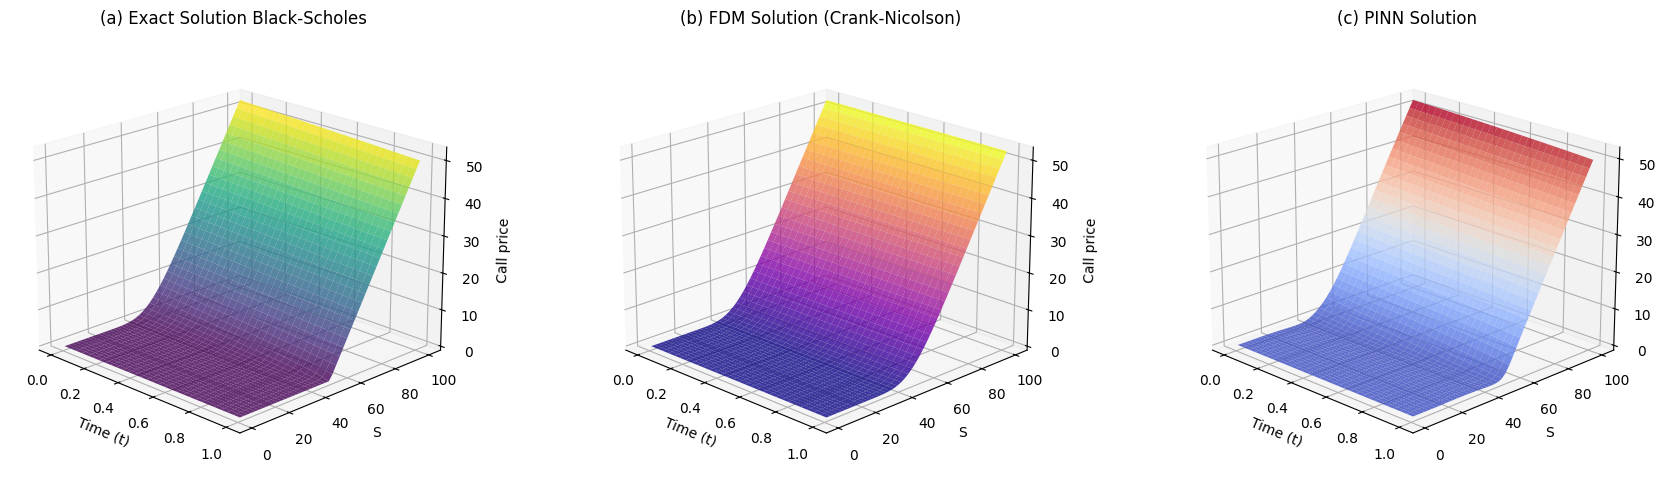

Analyse des erreurs 3D:
Erreur moyenne FDM: 0.849271
Erreur moyenne PINN: 0.131539
Erreur max FDM: 4.905147
Erreur max PINN: 0.651176


In [12]:
# Grille spatio-temporelle pour la visualisation 3D
S_3d = np.linspace(1, 100, 50)
t_3d = np.linspace(0, T, 30)
S_grid, t_grid = np.meshgrid(S_3d, t_3d)

# Solution exacte 3D
V_exact_3d = bs_call_price(S_grid, t_grid)

# Solution FDM 3D - recalcul pour chaque temps
V_fdm_3d = np.zeros_like(S_grid)
for i, t_val in enumerate(t_3d):
    # Recalculer FDM pour chaque temps
    S_fd, V_fd = crank_nicolson_call(S_max=200, M=200, N=200)
    V_fdm_3d[i] = np.interp(S_3d, S_fd, V_fd)

# Solution PINN 3D
V_pinn_3d = np.zeros_like(S_grid)
pinn_model.eval()
for i, t_val in enumerate(t_3d):
    S_eval_torch = torch.tensor(S_3d, dtype=torch.float32).view(-1,1).to(device)
    t_eval_torch = torch.ones_like(S_eval_torch) * t_val
    with torch.no_grad():
        V_pinn_3d[i] = pinn_model(torch.cat((S_eval_torch, t_eval_torch), dim=1)).cpu().numpy().flatten()

# Création des graphiques 3D avec orientation modifiée
fig = plt.figure(figsize=(18, 5))

# Solution exacte
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(t_grid, S_grid, V_exact_3d, cmap='viridis', alpha=0.8)
ax1.set_xlabel('Time (t)')
ax1.set_ylabel('S')
ax1.set_zlabel('Call price')
ax1.set_title('(a) Exact Solution Black-Scholes')
ax1.view_init(elev=20, azim=-45)

# Solution FDM
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(t_grid, S_grid, V_fdm_3d, cmap='plasma', alpha=0.8)
ax2.set_xlabel('Time (t)')
ax2.set_ylabel('S')
ax2.set_zlabel('Call price')
ax2.set_title('(b) FDM Solution (Crank-Nicolson)')
ax2.view_init(elev=20, azim=-45)

# Solution PINN
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(t_grid, S_grid, V_pinn_3d, cmap='coolwarm', alpha=0.8)
ax3.set_xlabel('Time (t)')
ax3.set_ylabel('S')
ax3.set_zlabel('Call price')
ax3.set_title('(c) PINN Solution')
ax3.view_init(elev=20, azim=-45)

plt.tight_layout()
plt.show()

# Calcul des erreurs pour analyse quantitative
error_fdm_3d = np.abs(V_fdm_3d - V_exact_3d)
error_pinn_3d = np.abs(V_pinn_3d - V_exact_3d)

print("Analyse des erreurs 3D:")
print(f"Erreur moyenne FDM: {np.mean(error_fdm_3d):.6f}")
print(f"Erreur moyenne PINN: {np.mean(error_pinn_3d):.6f}")
print(f"Erreur max FDM: {np.max(error_fdm_3d):.6f}")
print(f"Erreur max PINN: {np.max(error_pinn_3d):.6f}")

### 6.2 PINN vs Exact and MCS at t = 0


=== Entraînement PINN avec 1000 points de collocation ===
RMSE PINN pour 1000 points: 0.852355
RMSE MC pour 1000 paths: 0.337852

=== Entraînement PINN avec 2000 points de collocation ===
RMSE PINN pour 2000 points: 0.458022
RMSE MC pour 2000 paths: 0.578501

=== Entraînement PINN avec 5000 points de collocation ===
RMSE PINN pour 5000 points: 0.158211
RMSE MC pour 5000 paths: 0.212534


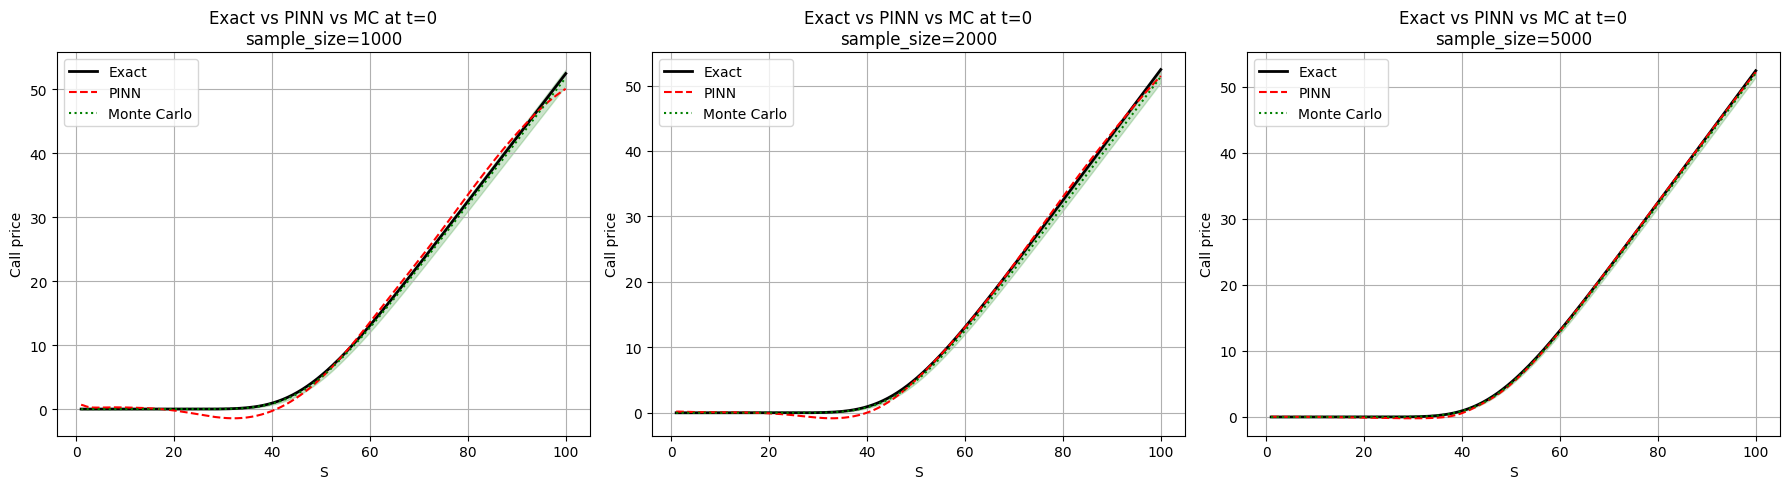

In [13]:
# Test avec différentes tailles d'échantillons pour le PINN vs Monte Carlo
sample_sizes = [1000, 2000, 5000]  # Points de collocation
epochs_list = [2000, 3000, 5000]    # Époques correspondantes

# Définir S_eval une seule fois pour toutes les évaluations
S_eval = np.linspace(1, 100, 200)
S_eval_torch = torch.tensor(S_eval, dtype=torch.float32).view(-1,1).to(device)
t0_torch = torch.zeros_like(S_eval_torch).to(device)
V_exact_eval = bs_call_price(S_eval, t=0.0)

# Créer UNE SEULE FIGURE avec 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (n_points, epochs) in enumerate(zip(sample_sizes, epochs_list)):
    print(f"\n=== Entraînement PINN avec {n_points} points de collocation ===")

    # Réinitialiser le modèle
    pinn_model = PINN_BSM(layers).to(device)
    optimizer = optim.Adam(pinn_model.parameters(), lr=1e-3)

    # Entraînement
    for epoch in range(epochs):
        pinn_model.train()
        optimizer.zero_grad()

        S_f, t_f, S_ic, t_ic, S_bc0, S_bcM, t_bc = sample_pinn_points(
            N_f=n_points, N_bc=200, N_ic=200, S_max=100.0
        )

        # Transférer sur device et activer gradients
        S_f = S_f.to(device); t_f = t_f.to(device)
        S_ic = S_ic.to(device); t_ic = t_ic.to(device)
        S_bc0 = S_bc0.to(device); S_bcM = S_bcM.to(device); t_bc = t_bc.to(device)
        S_f.requires_grad_(True)
        t_f.requires_grad_(True)

        # Calcul des losses
        f_res = pinn_bs_residual(pinn_model, S_f, t_f)
        loss_f = torch.mean(f_res**2)

        V_ic = pinn_model(torch.cat((S_ic, t_ic), dim=1))
        payoff = torch.clamp(S_ic - K, min=0.0)
        loss_ic = torch.mean((V_ic - payoff)**2)

        V_bc0 = pinn_model(torch.cat((S_bc0, t_bc), dim=1))
        loss_bc0 = torch.mean(V_bc0**2)

        V_bcM = pinn_model(torch.cat((S_bcM, t_bc), dim=1))
        target_bcM = S_bcM - K * torch.exp(-r * (T - t_bc))
        loss_bcM = torch.mean((V_bcM - target_bcM)**2)

        loss = loss_f + 50.0 * loss_ic + 10.0 * loss_bc0 + 10.0 * loss_bcM
        loss.backward()
        optimizer.step()

    # Évaluation PINN
    pinn_model.eval()
    with torch.no_grad():
        V_pinn = pinn_model(torch.cat((S_eval_torch, t0_torch), dim=1)).cpu().numpy().flatten()

    # Calcul Monte Carlo pour chaque point S
    V_mc = np.zeros_like(S_eval)
    mc_errors = np.zeros_like(S_eval)

    for j, S0 in enumerate(S_eval):
        mc_estimate, mc_std_err = mc_call_price(S0, N_paths=n_points)
        V_mc[j] = mc_estimate
        mc_errors[j] = mc_std_err

    rmse_pinn = np.sqrt(np.mean((V_pinn - V_exact_eval)**2))
    rmse_mc = np.sqrt(np.mean((V_mc - V_exact_eval)**2))
    print(f"RMSE PINN pour {n_points} points: {rmse_pinn:.6f}")
    print(f"RMSE MC pour {n_points} paths: {rmse_mc:.6f}")

    # Graphique
    ax = axes[i]
    ax.plot(S_eval, V_exact_eval, label="Exact", linewidth=2, color='black')
    ax.plot(S_eval, V_pinn, label="PINN", linestyle="--", color='red')
    ax.plot(S_eval, V_mc, label="Monte Carlo", linestyle=":", color='green')
    ax.fill_between(S_eval, V_mc - 2*mc_errors, V_mc + 2*mc_errors, alpha=0.2, color='green')
    ax.set_xlabel("S")
    ax.set_ylabel("Call price")
    ax.set_title(f"Exact vs PINN vs MC at t=0\nsample_size={n_points}")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


=== Entraînement PINN avec 1000 points de collocation ===
RMSE PINN : 0.994693
RMSE MC   : 0.337852

=== Entraînement PINN avec 2000 points de collocation ===
RMSE PINN : 0.584148
RMSE MC   : 0.578501

=== Entraînement PINN avec 5000 points de collocation ===
RMSE PINN : 0.145671
RMSE MC   : 0.212534


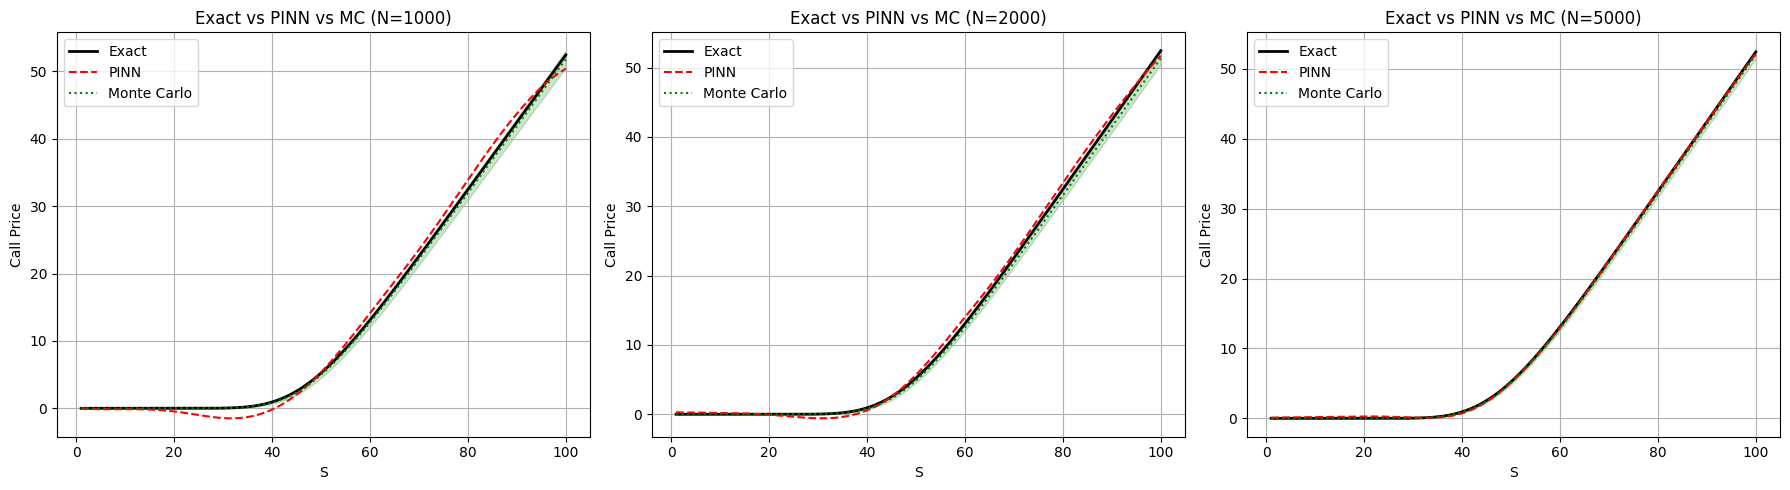


\begin{table}[htbp]
\centering
\caption{Performance comparison of PINN and Monte Carlo methods}
\label{tab:pinn_mc_metrics}
\renewcommand{\arraystretch}{1.2}
\resizebox{\textwidth}{!}{
\begin{tabular}{c|cccc|cccc}
\hline
\multirow{2}{*}{Sample Size} & \multicolumn{4}{c|}{PINN} & \multicolumn{4}{c}{Monte Carlo} \\
\cline{2-9}
& MAE & MSE & RMSE & Runtime (s) & MAE & MSE & RMSE & Runtime (s) \\
\hline
1000 & 0.853710 & 0.989415 & 0.994693 & 16.771 & 0.252075 & 0.114144 & 0.337852 & 0.035 \\
2000 & 0.505525 & 0.341229 & 0.584148 & 24.889 & 0.420576 & 0.334664 & 0.578501 & 0.028 \\
5000 & 0.126033 & 0.021220 & 0.145671 & 41.598 & 0.154870 & 0.045171 & 0.212534 & 0.045 \\
\hline
\end{tabular}}
\end{table}


In [14]:
import time
import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

# =========================================================
# Test avec différentes tailles d'échantillons : PINN vs MC
# =========================================================
sample_sizes = [1000, 2000, 5000]   # Points de collocation / paths MC
epochs_list = [2000, 3000, 5000]    # Époques PINN

# =========================================================
# Grille d’évaluation
# =========================================================
S_eval = np.linspace(1, 100, 200)
S_eval_torch = torch.tensor(S_eval, dtype=torch.float32).view(-1,1).to(device)
t0_torch = torch.zeros_like(S_eval_torch).to(device)
V_exact_eval = bs_call_price(S_eval, t=0.0)

# =========================================================
# Figure
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = []

for i, (n_points, epochs) in enumerate(zip(sample_sizes, epochs_list)):
    print(f"\n=== Entraînement PINN avec {n_points} points de collocation ===")

    # =====================================================
    # PINN
    # =====================================================
    pinn_model = PINN_BSM(layers).to(device)
    optimizer = optim.Adam(pinn_model.parameters(), lr=1e-3)

    start_time = time.time()
    for epoch in range(epochs):
        pinn_model.train()
        optimizer.zero_grad()

        S_f, t_f, S_ic, t_ic, S_bc0, S_bcM, t_bc = sample_pinn_points(
            N_f=n_points, N_bc=200, N_ic=200, S_max=100.0
        )

        S_f = S_f.to(device); t_f = t_f.to(device)
        S_ic = S_ic.to(device); t_ic = t_ic.to(device)
        S_bc0 = S_bc0.to(device); S_bcM = S_bcM.to(device); t_bc = t_bc.to(device)

        S_f.requires_grad_(True)
        t_f.requires_grad_(True)

        f_res = pinn_bs_residual(pinn_model, S_f, t_f)
        loss_f = torch.mean(f_res**2)

        V_ic = pinn_model(torch.cat((S_ic, t_ic), dim=1))
        payoff = torch.clamp(S_ic - K, min=0.0)
        loss_ic = torch.mean((V_ic - payoff)**2)

        V_bc0 = pinn_model(torch.cat((S_bc0, t_bc), dim=1))
        loss_bc0 = torch.mean(V_bc0**2)

        V_bcM = pinn_model(torch.cat((S_bcM, t_bc), dim=1))
        target_bcM = S_bcM - K * torch.exp(-r * (T - t_bc))
        loss_bcM = torch.mean((V_bcM - target_bcM)**2)

        loss = loss_f + 50.0 * loss_ic + 10.0 * loss_bc0 + 10.0 * loss_bcM
        loss.backward()
        optimizer.step()

    pinn_runtime = time.time() - start_time

    pinn_model.eval()
    with torch.no_grad():
        V_pinn = pinn_model(torch.cat((S_eval_torch, t0_torch), dim=1)).cpu().numpy().flatten()

    # =====================================================
    # Monte Carlo
    # =====================================================
    start_time = time.time()
    V_mc = np.zeros_like(S_eval)
    mc_errors = np.zeros_like(S_eval)

    for j, S0 in enumerate(S_eval):
        mc_estimate, mc_std_err = mc_call_price(S0, N_paths=n_points)
        V_mc[j] = mc_estimate
        mc_errors[j] = mc_std_err

    mc_runtime = time.time() - start_time

    # =====================================================
    # Metrics
    # =====================================================
    mae_pinn = np.mean(np.abs(V_pinn - V_exact_eval))
    mse_pinn = np.mean((V_pinn - V_exact_eval)**2)
    rmse_pinn = np.sqrt(mse_pinn)

    mae_mc = np.mean(np.abs(V_mc - V_exact_eval))
    mse_mc = np.mean((V_mc - V_exact_eval)**2)
    rmse_mc = np.sqrt(mse_mc)

    metrics.append([
        n_points,
        mae_pinn, mse_pinn, rmse_pinn, pinn_runtime,
        mae_mc, mse_mc, rmse_mc, mc_runtime
    ])

    print(f"RMSE PINN : {rmse_pinn:.6f}")
    print(f"RMSE MC   : {rmse_mc:.6f}")

    # =====================================================
    # Plot
    # =====================================================
    ax = axes[i]
    ax.plot(S_eval, V_exact_eval, label="Exact", linewidth=2, color="black")
    ax.plot(S_eval, V_pinn, "--", label="PINN", color="red")
    ax.plot(S_eval, V_mc, ":", label="Monte Carlo", color="green")
    ax.fill_between(S_eval, V_mc - 2*mc_errors, V_mc + 2*mc_errors,
                    alpha=0.2, color="green")
    ax.set_title(f"Exact vs PINN vs MC (N={n_points})")
    ax.set_xlabel("S")
    ax.set_ylabel("Call Price")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

# =========================================================
# Tableau LaTeX : PINN vs Monte Carlo
# =========================================================
print("\n\\begin{table}[htbp]")
print("\\centering")
print("\\caption{Performance comparison of PINN and Monte Carlo methods}")
print("\\label{tab:pinn_mc_metrics}")
print("\\renewcommand{\\arraystretch}{1.2}")
print("\\resizebox{\\textwidth}{!}{")
print("\\begin{tabular}{c|cccc|cccc}")
print("\\hline")
print("\\multirow{2}{*}{Sample Size} & \\multicolumn{4}{c|}{PINN} & \\multicolumn{4}{c}{Monte Carlo} \\\\")
print("\\cline{2-9}")
print("& MAE & MSE & RMSE & Runtime (s) & MAE & MSE & RMSE & Runtime (s) \\\\")
print("\\hline")

for row in metrics:
    print(f"{row[0]} "
          f"& {row[1]:.6f} & {row[2]:.6f} & {row[3]:.6f} & {row[4]:.3f} "
          f"& {row[5]:.6f} & {row[6]:.6f} & {row[7]:.6f} & {row[8]:.3f} \\\\")

print("\\hline")
print("\\end{tabular}}")
print("\\end{table}")



=== Calcul des solutions 3D PINN vs Monte Carlo ===
Calcul des solutions Monte Carlo 3D...


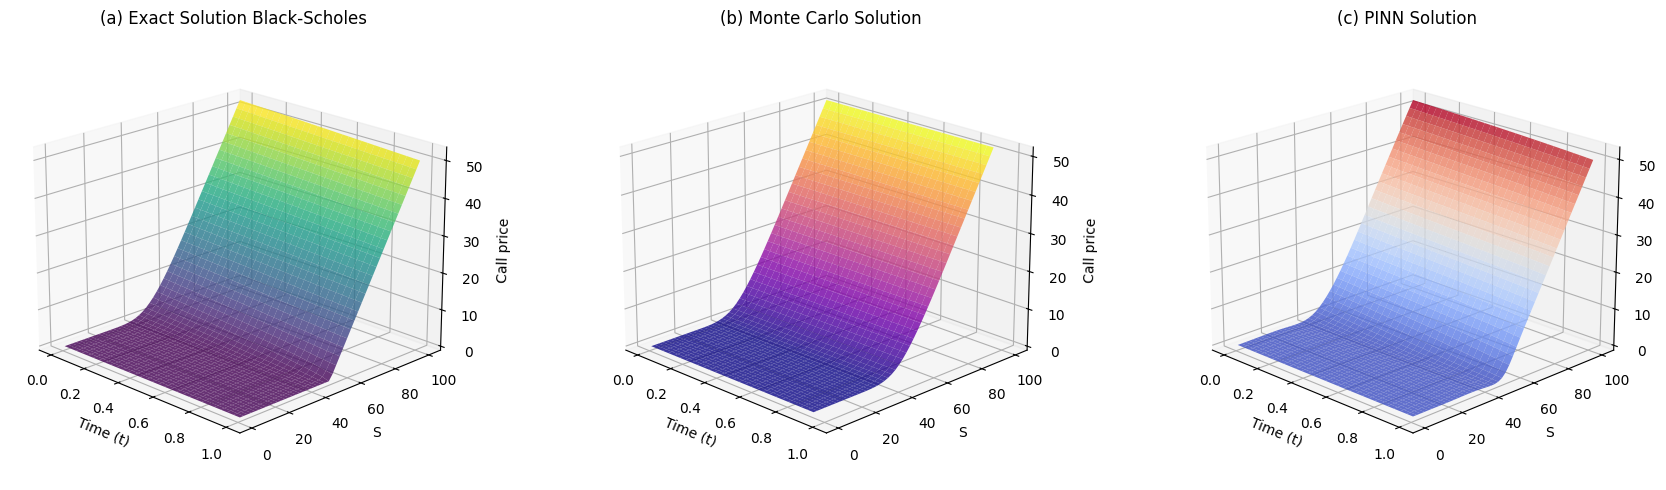


Analyse des erreurs 3D:
Erreur moyenne Monte Carlo: nan
Erreur moyenne PINN: 0.104229
Erreur max Monte Carlo: nan
Erreur max PINN: 0.649820


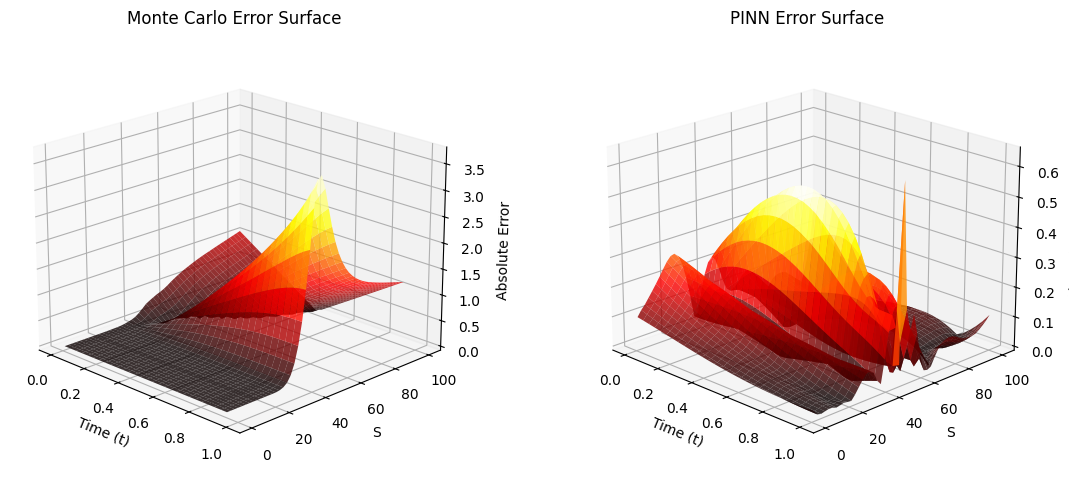

In [15]:
# Représentation 3D pour PINN vs Exact vs Monte Carlo
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Grille spatio-temporelle (identique à l'autre code)
S_3d = np.linspace(1, 100, 50)
t_3d = np.linspace(0, T, 30)
t_grid, S_grid = np.meshgrid(t_3d, S_3d)  # Même structure que pour FDM

# Solution exacte 3D
V_exact_3d = bs_call_price(S_grid, t_grid)

# Solution PINN 3D - utiliser le PINN entraîné avec 5000 points
print("\n=== Calcul des solutions 3D PINN vs Monte Carlo ===")

# Utiliser le dernier PINN entraîné (5000 points)
pinn_model.eval()
V_pinn_3d = np.zeros_like(S_grid)

for i, t_val in enumerate(t_3d):
    S_eval_torch = torch.tensor(S_3d, dtype=torch.float32).view(-1,1).to(device)
    t_eval_torch = torch.ones_like(S_eval_torch) * t_val
    with torch.no_grad():
        V_pinn_3d[:, i] = pinn_model(torch.cat((S_eval_torch, t_eval_torch), dim=1)).cpu().numpy().flatten()

# Solution Monte Carlo 3D - échantillonnage plus léger pour 3D
print("Calcul des solutions Monte Carlo 3D...")
V_mc_3d = np.zeros_like(S_grid)

# Pour Monte Carlo 3D, on prend un sous-échantillon pour performance
# On évalue seulement aux nœuds de la grille
for i in range(len(S_3d)):
    for j in range(len(t_3d)):
        if j % 3 == 0:  # Échantillonner seulement 1/3 des points temporels
            mc_estimate, _ = mc_call_price(S_3d[i], N_paths=2000)
            V_mc_3d[i, j] = mc_estimate
        else:
            # Interpolation linéaire pour les autres points
            V_mc_3d[i, j] = np.nan

# Interpolation pour remplir les valeurs manquantes
from scipy import interpolate

# Créer masque des points valides
valid_mask = ~np.isnan(V_mc_3d)
if np.sum(valid_mask) > 0:
    # Points valides
    valid_points = np.column_stack((t_grid[valid_mask], S_grid[valid_mask]))
    valid_values = V_mc_3d[valid_mask]

    # Interpolation
    interp_func = interpolate.LinearNDInterpolator(valid_points, valid_values)
    all_points = np.column_stack((t_grid.flatten(), S_grid.flatten()))
    V_mc_3d_interp = interp_func(all_points).reshape(S_grid.shape)

    # Remplacer les valeurs interpolées
    V_mc_3d = np.where(~valid_mask, V_mc_3d_interp, V_mc_3d)

# Création des graphiques 3D
fig = plt.figure(figsize=(18, 5))

# Solution exacte
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(t_grid, S_grid, V_exact_3d, cmap='viridis', alpha=0.8)
ax1.set_xlabel('Time (t)')
ax1.set_ylabel('S')
ax1.set_zlabel('Call price')
ax1.set_title('(a) Exact Solution Black-Scholes')
ax1.view_init(elev=20, azim=-45)

# Solution Monte Carlo
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(t_grid, S_grid, V_mc_3d, cmap='plasma', alpha=0.8)
ax2.set_xlabel('Time (t)')
ax2.set_ylabel('S')
ax2.set_zlabel('Call price')
ax2.set_title('(b) Monte Carlo Solution')
ax2.view_init(elev=20, azim=-45)

# Solution PINN
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(t_grid, S_grid, V_pinn_3d, cmap='coolwarm', alpha=0.8)
ax3.set_xlabel('Time (t)')
ax3.set_ylabel('S')
ax3.set_zlabel('Call price')
ax3.set_title('(c) PINN Solution')
ax3.view_init(elev=20, azim=-45)

plt.tight_layout()
plt.savefig('3D_PINN_vs_MC.png', dpi=300, bbox_inches='tight')
plt.show()

# Calcul des erreurs pour analyse quantitative
error_mc_3d = np.abs(V_mc_3d - V_exact_3d)
error_pinn_3d = np.abs(V_pinn_3d - V_exact_3d)

print("\nAnalyse des erreurs 3D:")
print(f"Erreur moyenne Monte Carlo: {np.mean(error_mc_3d):.6f}")
print(f"Erreur moyenne PINN: {np.mean(error_pinn_3d):.6f}")
print(f"Erreur max Monte Carlo: {np.max(error_mc_3d):.6f}")
print(f"Erreur max PINN: {np.max(error_pinn_3d):.6f}")

# Visualisation des erreurs
fig2 = plt.figure(figsize=(12, 5))

ax4 = fig2.add_subplot(121, projection='3d')
surf4 = ax4.plot_surface(t_grid, S_grid, error_mc_3d, cmap='hot', alpha=0.8)
ax4.set_xlabel('Time (t)')
ax4.set_ylabel('S')
ax4.set_zlabel('Absolute Error')
ax4.set_title('Monte Carlo Error Surface')
ax4.view_init(elev=20, azim=-45)

ax5 = fig2.add_subplot(122, projection='3d')
surf5 = ax5.plot_surface(t_grid, S_grid, error_pinn_3d, cmap='hot', alpha=0.8)
ax5.set_xlabel('Time (t)')
ax5.set_ylabel('S')
ax5.set_zlabel('Absolute Error')
ax5.set_title('PINN Error Surface')
ax5.view_init(elev=20, azim=-45)

plt.tight_layout()
plt.savefig('3D_Error_PINN_MC.png', dpi=300, bbox_inches='tight')
plt.show()

##Comparative Summary: PINN vs ANN vs Exact


=== Comparaison avec 50 points ===
Entraînement ANN avec 50 points...
Entraînement PINN avec 50 points de collocation...
RMSE ANN (50 points): 0.986712
RMSE PINN (50 points): 0.957165

=== Comparaison avec 200 points ===
Entraînement ANN avec 200 points...
Entraînement PINN avec 200 points de collocation...
RMSE ANN (200 points): 1.072685
RMSE PINN (200 points): 0.573899

=== Comparaison avec 500 points ===
Entraînement ANN avec 500 points...
Entraînement PINN avec 500 points de collocation...
RMSE ANN (500 points): 1.097674
RMSE PINN (500 points): 0.315235


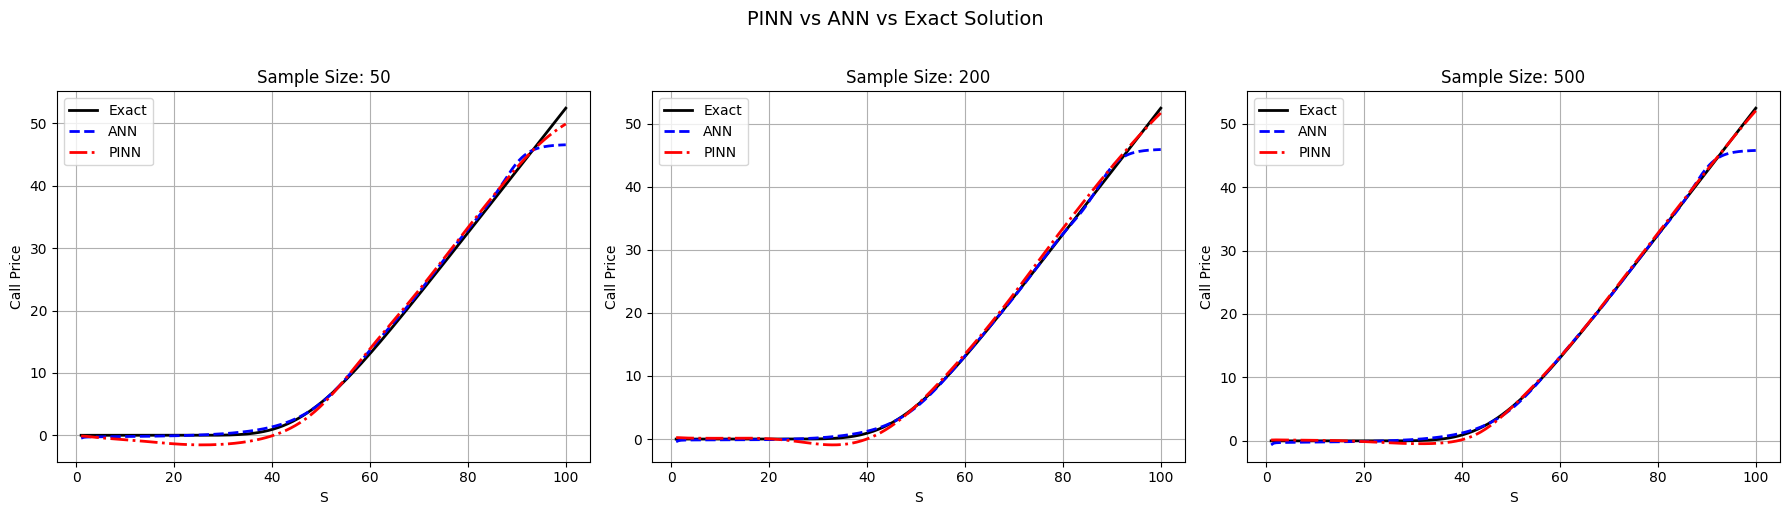

In [16]:
# Comparative analysis: PINN vs Exact vs ANN avec tailles comparables
sample_sizes = [50, 200, 500]  # Tailles comparables pour PINN et ANN
epochs_list = [2000, 3000, 4000]  # Époques proportionnelles

# Définir S_eval
S_eval = np.linspace(1, 100, 200)
V_exact_eval = bs_call_price(S_eval, t=0.0)

# Créer UNE SEULE FIGURE avec 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (n_points, epochs) in enumerate(zip(sample_sizes, epochs_list)):
    print(f"\n=== Comparaison avec {n_points} points ===")

    # 1. Entraînement ANN
    print(f"Entraînement ANN avec {n_points} points...")

    # Générer données d'entraînement pour ANN
    S_train = np.linspace(1, 100, n_points)
    y_train = bs_call_price(S_train, t=0.0)
    S_train_t = torch.tensor(S_train, dtype=torch.float32).view(-1,1).to(device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1,1).to(device)

    # Créer et entraîner ANN
    ann_model = SimpleANN().to(device)
    optimizer_ann = optim.Adam(ann_model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    for epoch in range(3000):
        ann_model.train()
        optimizer_ann.zero_grad()
        pred = ann_model(S_train_t)
        loss = loss_fn(pred, y_train_t)
        loss.backward()
        optimizer_ann.step()

    # 2. Entraînement PINN
    print(f"Entraînement PINN avec {n_points} points de collocation...")

    pinn_model = PINN_BSM([2, 64, 64, 64, 1]).to(device)
    optimizer_pinn = optim.Adam(pinn_model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        pinn_model.train()
        optimizer_pinn.zero_grad()

        S_f, t_f, S_ic, t_ic, S_bc0, S_bcM, t_bc = sample_pinn_points(
            N_f=n_points, N_bc=200, N_ic=200, S_max=100.0
        )

        # Transfert et activation gradients
        S_f = S_f.to(device); t_f = t_f.to(device)
        S_ic = S_ic.to(device); t_ic = t_ic.to(device)
        S_bc0 = S_bc0.to(device); S_bcM = S_bcM.to(device); t_bc = t_bc.to(device)
        S_f.requires_grad_(True)
        t_f.requires_grad_(True)

        # Calcul des losses PINN
        f_res = pinn_bs_residual(pinn_model, S_f, t_f)
        loss_f = torch.mean(f_res**2)

        V_ic = pinn_model(torch.cat((S_ic, t_ic), dim=1))
        payoff = torch.clamp(S_ic - K, min=0.0)
        loss_ic = torch.mean((V_ic - payoff)**2)

        V_bc0 = pinn_model(torch.cat((S_bc0, t_bc), dim=1))
        loss_bc0 = torch.mean(V_bc0**2)

        V_bcM = pinn_model(torch.cat((S_bcM, t_bc), dim=1))
        target_bcM = S_bcM - K * torch.exp(-r * (T - t_bc))
        loss_bcM = torch.mean((V_bcM - target_bcM)**2)

        loss = loss_f + 50.0 * loss_ic + 10.0 * loss_bc0 + 10.0 * loss_bcM
        loss.backward()
        optimizer_pinn.step()

    # 3. Évaluations
    # ANN
    ann_model.eval()
    S_eval_torch = torch.tensor(S_eval, dtype=torch.float32).view(-1,1).to(device)
    with torch.no_grad():
        V_ann = ann_model(S_eval_torch).cpu().numpy().flatten()

    # PINN
    pinn_model.eval()
    t0_torch = torch.zeros_like(S_eval_torch).to(device)
    with torch.no_grad():
        V_pinn = pinn_model(torch.cat((S_eval_torch, t0_torch), dim=1)).cpu().numpy().flatten()

    # Calcul des RMSE
    rmse_ann = np.sqrt(np.mean((V_ann - V_exact_eval)**2))
    rmse_pinn = np.sqrt(np.mean((V_pinn - V_exact_eval)**2))

    print(f"RMSE ANN ({n_points} points): {rmse_ann:.6f}")
    print(f"RMSE PINN ({n_points} points): {rmse_pinn:.6f}")

    # 4. Graphique
    ax = axes[i]
    ax.plot(S_eval, V_exact_eval, label='Exact', linewidth=2, color='black')
    ax.plot(S_eval, V_ann, label='ANN', linestyle='--', linewidth=2, color='blue')
    ax.plot(S_eval, V_pinn, label='PINN', linestyle='-.', linewidth=2, color='red')

    ax.set_xlabel('S')
    ax.set_ylabel('Call Price')
    ax.set_title(f'Sample Size: {n_points}')
    ax.legend()
    ax.grid(True)

plt.suptitle('PINN vs ANN vs Exact Solution', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('PINN_vs_ANN.png', dpi=300, bbox_inches='tight')
plt.show()


=== Comparaison avec 50 points ===

=== Comparaison avec 200 points ===

=== Comparaison avec 500 points ===


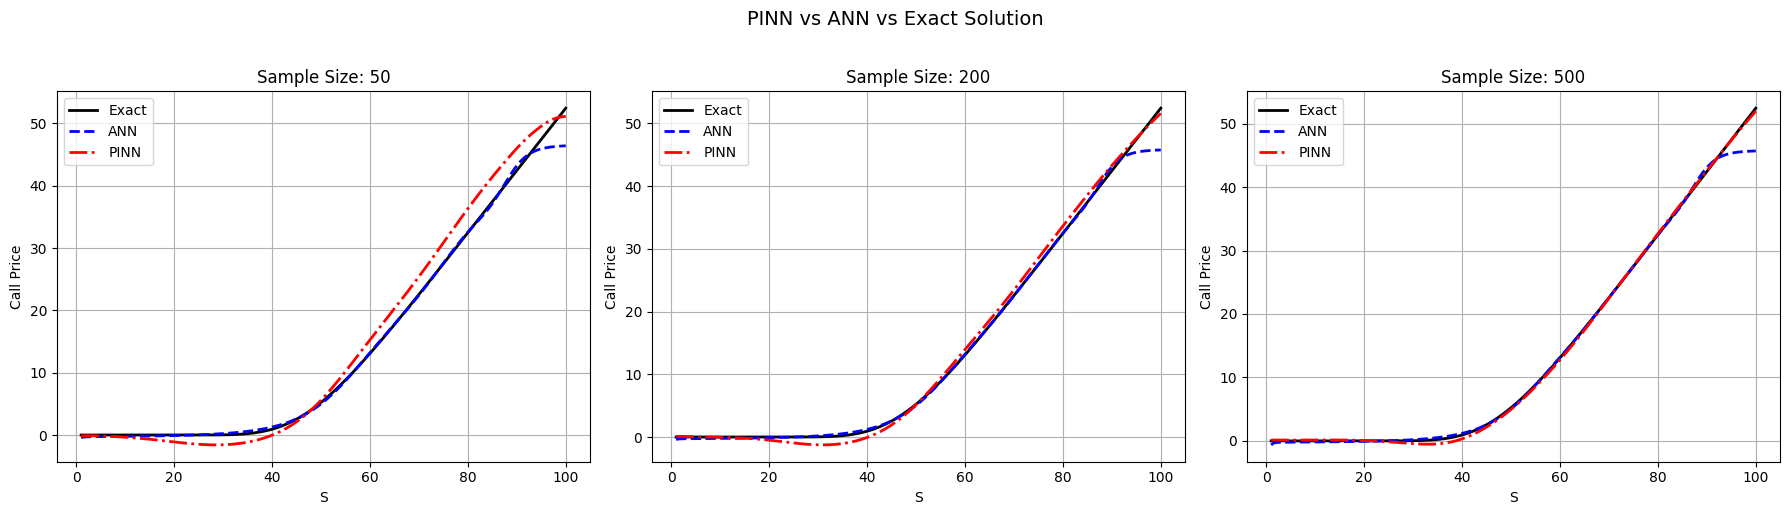


\begin{table}[htbp]
\centering
\caption{Performance comparison of ANN and PINN methods}
\label{tab:metrics_comparison}
\renewcommand{\arraystretch}{1.2}
\begin{tabular}{c|cccc|cccc}
\hline
\multirow{2}{*}{Sample Size} & \multicolumn{4}{c|}{ANN} & \multicolumn{4}{c}{PINN} \\
\cline{2-9}
& MAE & MSE & RMSE & Runtime (s) & MAE & MSE & RMSE & Runtime (s) \\
\hline
50 & 0.395120 & 0.940687 & 0.969890 & 4.539 & 1.732718 & 4.527125 & 2.127704 & 17.400 \\
200 & 0.402960 & 1.203795 & 1.097176 & 4.591 & 0.698573 & 0.658133 & 0.811254 & 26.154 \\
500 & 0.392441 & 1.238759 & 1.112996 & 4.132 & 0.246354 & 0.091245 & 0.302068 & 35.530 \\
\hline
\end{tabular}
\end{table}


In [17]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# =========================================================
# Comparative analysis: PINN vs Exact vs ANN
# =========================================================
sample_sizes = [50, 200, 500]
epochs_list = [2000, 3000, 4000]

# =========================================================
# Evaluation grid
# =========================================================
S_eval = np.linspace(1, 100, 200)
V_exact_eval = bs_call_price(S_eval, t=0.0)

S_eval_torch = torch.tensor(S_eval, dtype=torch.float32).view(-1, 1).to(device)
t0_torch = torch.zeros_like(S_eval_torch).to(device)

# =========================================================
# Figure
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = []

for i, (n_points, epochs) in enumerate(zip(sample_sizes, epochs_list)):
    print(f"\n=== Comparaison avec {n_points} points ===")

    # =====================================================
    # ANN
    # =====================================================
    S_train = np.linspace(1, 100, n_points)
    y_train = bs_call_price(S_train, t=0.0)

    S_train_t = torch.tensor(S_train, dtype=torch.float32).view(-1, 1).to(device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)

    ann_model = SimpleANN().to(device)
    optimizer_ann = optim.Adam(ann_model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    start_time = time.time()
    for epoch in range(3000):
        ann_model.train()
        optimizer_ann.zero_grad()
        pred = ann_model(S_train_t)
        loss = loss_fn(pred, y_train_t)
        loss.backward()
        optimizer_ann.step()
    ann_runtime = time.time() - start_time

    ann_model.eval()
    with torch.no_grad():
        V_ann = ann_model(S_eval_torch).cpu().numpy().flatten()

    mae_ann = np.mean(np.abs(V_ann - V_exact_eval))
    mse_ann = np.mean((V_ann - V_exact_eval) ** 2)
    rmse_ann = np.sqrt(mse_ann)

    # =====================================================
    # PINN
    # =====================================================
    pinn_model = PINN_BSM([2, 64, 64, 64, 1]).to(device)
    optimizer_pinn = optim.Adam(pinn_model.parameters(), lr=1e-3)

    start_time = time.time()
    for epoch in range(epochs):
        pinn_model.train()
        optimizer_pinn.zero_grad()

        S_f, t_f, S_ic, t_ic, S_bc0, S_bcM, t_bc = sample_pinn_points(
            N_f=n_points, N_bc=200, N_ic=200, S_max=100.0
        )

        S_f = S_f.to(device); t_f = t_f.to(device)
        S_ic = S_ic.to(device); t_ic = t_ic.to(device)
        S_bc0 = S_bc0.to(device); S_bcM = S_bcM.to(device); t_bc = t_bc.to(device)

        S_f.requires_grad_(True)
        t_f.requires_grad_(True)

        f_res = pinn_bs_residual(pinn_model, S_f, t_f)
        loss_f = torch.mean(f_res ** 2)

        V_ic = pinn_model(torch.cat((S_ic, t_ic), dim=1))
        payoff = torch.clamp(S_ic - K, min=0.0)
        loss_ic = torch.mean((V_ic - payoff) ** 2)

        V_bc0 = pinn_model(torch.cat((S_bc0, t_bc), dim=1))
        loss_bc0 = torch.mean(V_bc0 ** 2)

        V_bcM = pinn_model(torch.cat((S_bcM, t_bc), dim=1))
        target_bcM = S_bcM - K * torch.exp(-r * (T - t_bc))
        loss_bcM = torch.mean((V_bcM - target_bcM) ** 2)

        loss = loss_f + 50.0 * loss_ic + 10.0 * loss_bc0 + 10.0 * loss_bcM
        loss.backward()
        optimizer_pinn.step()

    pinn_runtime = time.time() - start_time

    pinn_model.eval()
    with torch.no_grad():
        V_pinn = pinn_model(torch.cat((S_eval_torch, t0_torch), dim=1)).cpu().numpy().flatten()

    mae_pinn = np.mean(np.abs(V_pinn - V_exact_eval))
    mse_pinn = np.mean((V_pinn - V_exact_eval) ** 2)
    rmse_pinn = np.sqrt(mse_pinn)

    metrics.append([
        n_points,
        mae_ann, mse_ann, rmse_ann, ann_runtime,
        mae_pinn, mse_pinn, rmse_pinn, pinn_runtime
    ])

    # =====================================================
    # Plot
    # =====================================================
    ax = axes[i]
    ax.plot(S_eval, V_exact_eval, label="Exact", linewidth=2, color="black")
    ax.plot(S_eval, V_ann, "--", label="ANN", linewidth=2, color="blue")
    ax.plot(S_eval, V_pinn, "-.", label="PINN", linewidth=2, color="red")
    ax.set_title(f"Sample Size: {n_points}")
    ax.set_xlabel("S")
    ax.set_ylabel("Call Price")
    ax.grid(True)
    ax.legend()

plt.suptitle("PINN vs ANN vs Exact Solution", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("PINN_vs_ANN.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# LaTeX Table
# =========================================================
print("\n\\begin{table}[htbp]")
print("\\centering")
print("\\caption{Performance comparison of ANN and PINN methods}")
print("\\label{tab:metrics_comparison}")
print("\\renewcommand{\\arraystretch}{1.2}")
print("\\begin{tabular}{c|cccc|cccc}")
print("\\hline")
print("\\multirow{2}{*}{Sample Size} & \\multicolumn{4}{c|}{ANN} & \\multicolumn{4}{c}{PINN} \\\\")
print("\\cline{2-9}")
print("& MAE & MSE & RMSE & Runtime (s) & MAE & MSE & RMSE & Runtime (s) \\\\")
print("\\hline")

for row in metrics:
    print(f"{row[0]} "
          f"& {row[1]:.6f} & {row[2]:.6f} & {row[3]:.6f} & {row[4]:.3f} "
          f"& {row[5]:.6f} & {row[6]:.6f} & {row[7]:.6f} & {row[8]:.3f} \\\\")

print("\\hline")
print("\\end{tabular}")
print("\\end{table}")



=== Calcul des solutions 3D PINN vs ANN ===
Entraînement ANN pour visualisation 3D...


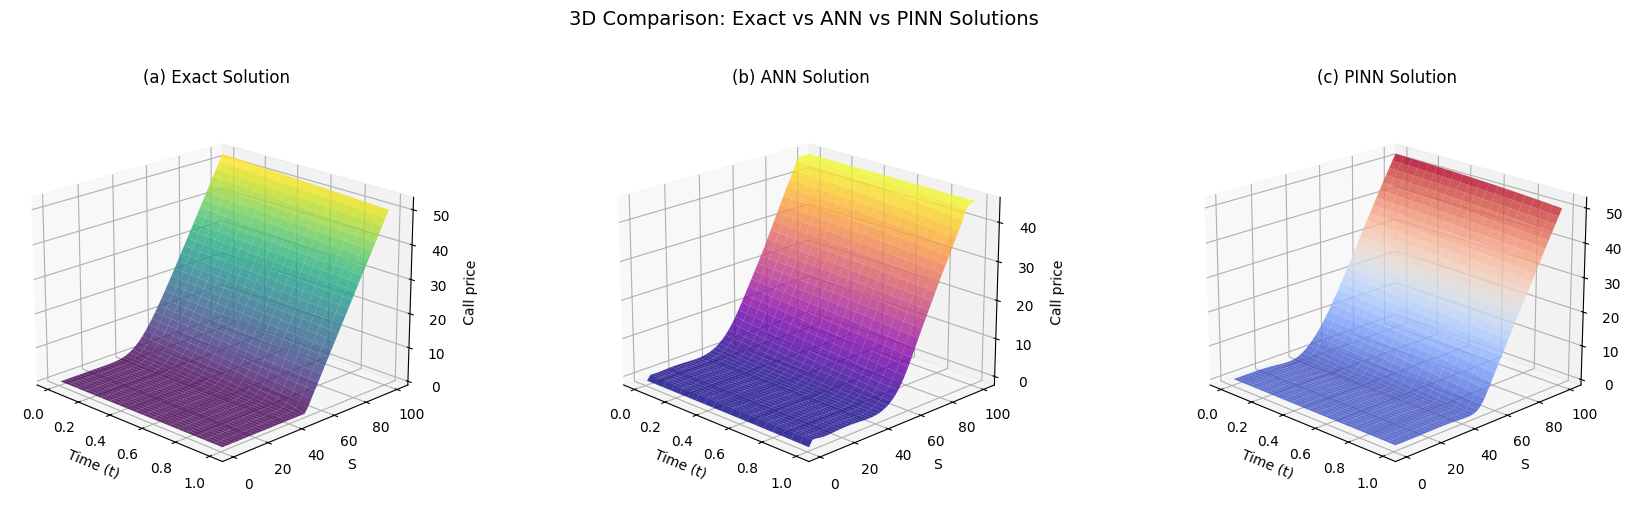


=== Analyse des erreurs 3D ===
Erreur moyenne ANN 3D: 0.378400
Erreur moyenne PINN 3D: 0.180915
Erreur max ANN 3D: 7.062672
Erreur max PINN 3D: 0.823563


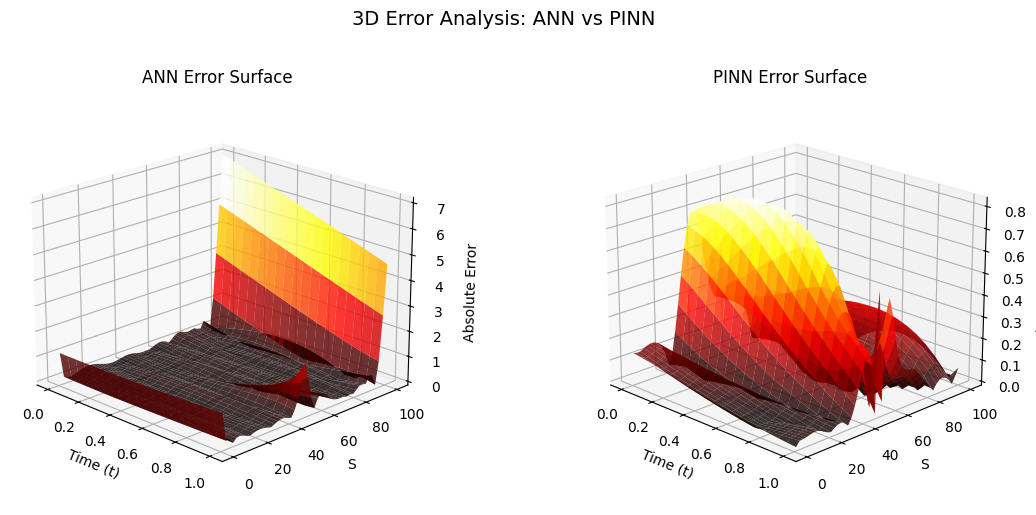

In [18]:
# Représentation 3D pour PINN vs ANN vs Exact
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Grille spatio-temporelle
S_3d = np.linspace(1, 100, 50)
t_3d = np.linspace(0, T, 20)
t_grid, S_grid = np.meshgrid(t_3d, S_3d)

# Solution exacte 3D
V_exact_3d = bs_call_price(S_grid, t_grid)

print("\n=== Calcul des solutions 3D PINN vs ANN ===")

# Utiliser le PINN entraîné avec 1000 points (dernier de la comparaison)
pinn_model.eval()
V_pinn_3d = np.zeros_like(S_grid)

for i, t_val in enumerate(t_3d):
    S_eval_torch = torch.tensor(S_3d, dtype=torch.float32).view(-1,1).to(device)
    t_eval_torch = torch.ones_like(S_eval_torch) * t_val
    with torch.no_grad():
        V_pinn_3d[:, i] = pinn_model(torch.cat((S_eval_torch, t_eval_torch), dim=1)).cpu().numpy().flatten()

# Solution ANN 3D - entraîner un ANN sur grille 2D
print("Entraînement ANN pour visualisation 3D...")

# Créer données d'entraînement pour ANN (points espacés)
n_train_3d = 500
S_train_3d = np.random.uniform(1, 100, n_train_3d)
t_train_3d = np.random.uniform(0, T, n_train_3d)
V_train_3d = bs_call_price(S_train_3d, t_train_3d)

# Préparer données
X_train = np.column_stack((S_train_3d, t_train_3d))
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(V_train_3d, dtype=torch.float32).view(-1,1).to(device)

# Entraîner ANN 2D
ann_3d_model = nn.Sequential(
    nn.Linear(2, 32),
    nn.Tanh(),
    nn.Linear(32, 32),
    nn.Tanh(),
    nn.Linear(32, 32),
    nn.Tanh(),
    nn.Linear(32, 1)
).to(device)

optimizer_3d = optim.Adam(ann_3d_model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(3000):
    ann_3d_model.train()
    optimizer_3d.zero_grad()
    pred = ann_3d_model(X_train_t)
    loss = loss_fn(pred, y_train_t)
    loss.backward()
    optimizer_3d.step()

# Évaluation ANN 3D
ann_3d_model.eval()
V_ann_3d = np.zeros_like(S_grid)

for i in range(len(S_3d)):
    for j in range(len(t_3d)):
        X_point = torch.tensor([[S_3d[i], t_3d[j]]], dtype=torch.float32).to(device)
        with torch.no_grad():
            V_ann_3d[i, j] = ann_3d_model(X_point).cpu().numpy().flatten()[0]

# Création des graphiques 3D
fig = plt.figure(figsize=(18, 5))

# Solution exacte
ax1 = fig.add_subplot(131, projection='3d')
surf1 = ax1.plot_surface(t_grid, S_grid, V_exact_3d, cmap='viridis', alpha=0.8)
ax1.set_xlabel('Time (t)')
ax1.set_ylabel('S')
ax1.set_zlabel('Call price')
ax1.set_title('(a) Exact Solution')
ax1.view_init(elev=20, azim=-45)

# Solution ANN
ax2 = fig.add_subplot(132, projection='3d')
surf2 = ax2.plot_surface(t_grid, S_grid, V_ann_3d, cmap='plasma', alpha=0.8)
ax2.set_xlabel('Time (t)')
ax2.set_ylabel('S')
ax2.set_zlabel('Call price')
ax2.set_title('(b) ANN Solution ')
ax2.view_init(elev=20, azim=-45)

# Solution PINN
ax3 = fig.add_subplot(133, projection='3d')
surf3 = ax3.plot_surface(t_grid, S_grid, V_pinn_3d, cmap='coolwarm', alpha=0.8)
ax3.set_xlabel('Time (t)')
ax3.set_ylabel('S')
ax3.set_zlabel('Call price')
ax3.set_title('(c) PINN Solution ')
ax3.view_init(elev=20, azim=-45)

plt.suptitle('3D Comparison: Exact vs ANN vs PINN Solutions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('3D_PINN_vs_ANN.png', dpi=300, bbox_inches='tight')
plt.show()

# Calcul des erreurs
error_ann_3d = np.abs(V_ann_3d - V_exact_3d)
error_pinn_3d = np.abs(V_pinn_3d - V_exact_3d)

print("\n=== Analyse des erreurs 3D ===")
print(f"Erreur moyenne ANN 3D: {np.mean(error_ann_3d):.6f}")
print(f"Erreur moyenne PINN 3D: {np.mean(error_pinn_3d):.6f}")
print(f"Erreur max ANN 3D: {np.max(error_ann_3d):.6f}")
print(f"Erreur max PINN 3D: {np.max(error_pinn_3d):.6f}")

# Visualisation des erreurs
fig2 = plt.figure(figsize=(12, 5))

ax4 = fig2.add_subplot(121, projection='3d')
surf4 = ax4.plot_surface(t_grid, S_grid, error_ann_3d, cmap='hot', alpha=0.8)
ax4.set_xlabel('Time (t)')
ax4.set_ylabel('S')
ax4.set_zlabel('Absolute Error')
ax4.set_title('ANN Error Surface')
ax4.view_init(elev=20, azim=-45)

ax5 = fig2.add_subplot(122, projection='3d')
surf5 = ax5.plot_surface(t_grid, S_grid, error_pinn_3d, cmap='hot', alpha=0.8)
ax5.set_xlabel('Time (t)')
ax5.set_ylabel('S')
ax5.set_zlabel('Absolute Error')
ax5.set_title('PINN Error Surface')
ax5.view_init(elev=20, azim=-45)

plt.suptitle('3D Error Analysis: ANN vs PINN', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('3D_Error_PINN_ANN.png', dpi=300, bbox_inches='tight')
plt.show()

COMPARISON OF METHODS FOR DIFFERENT SAMPLE SIZES
Sample sizes: [500, 1000, 1500, 2000]

Processing sample size 1/4: 500

Processing sample size: 500
  Running FDM...
  Training ANN...
  Training PINN...
  Running Monte Carlo...

Processing sample size 2/4: 1000

Processing sample size: 1000
  Running FDM...
  Training ANN...
  Training PINN...
  Running Monte Carlo...

Processing sample size 3/4: 1500

Processing sample size: 1500
  Running FDM...
  Training ANN...
  Training PINN...
  Running Monte Carlo...

Processing sample size 4/4: 2000

Processing sample size: 2000
  Running FDM...
  Training ANN...
  Training PINN...
  Running Monte Carlo...


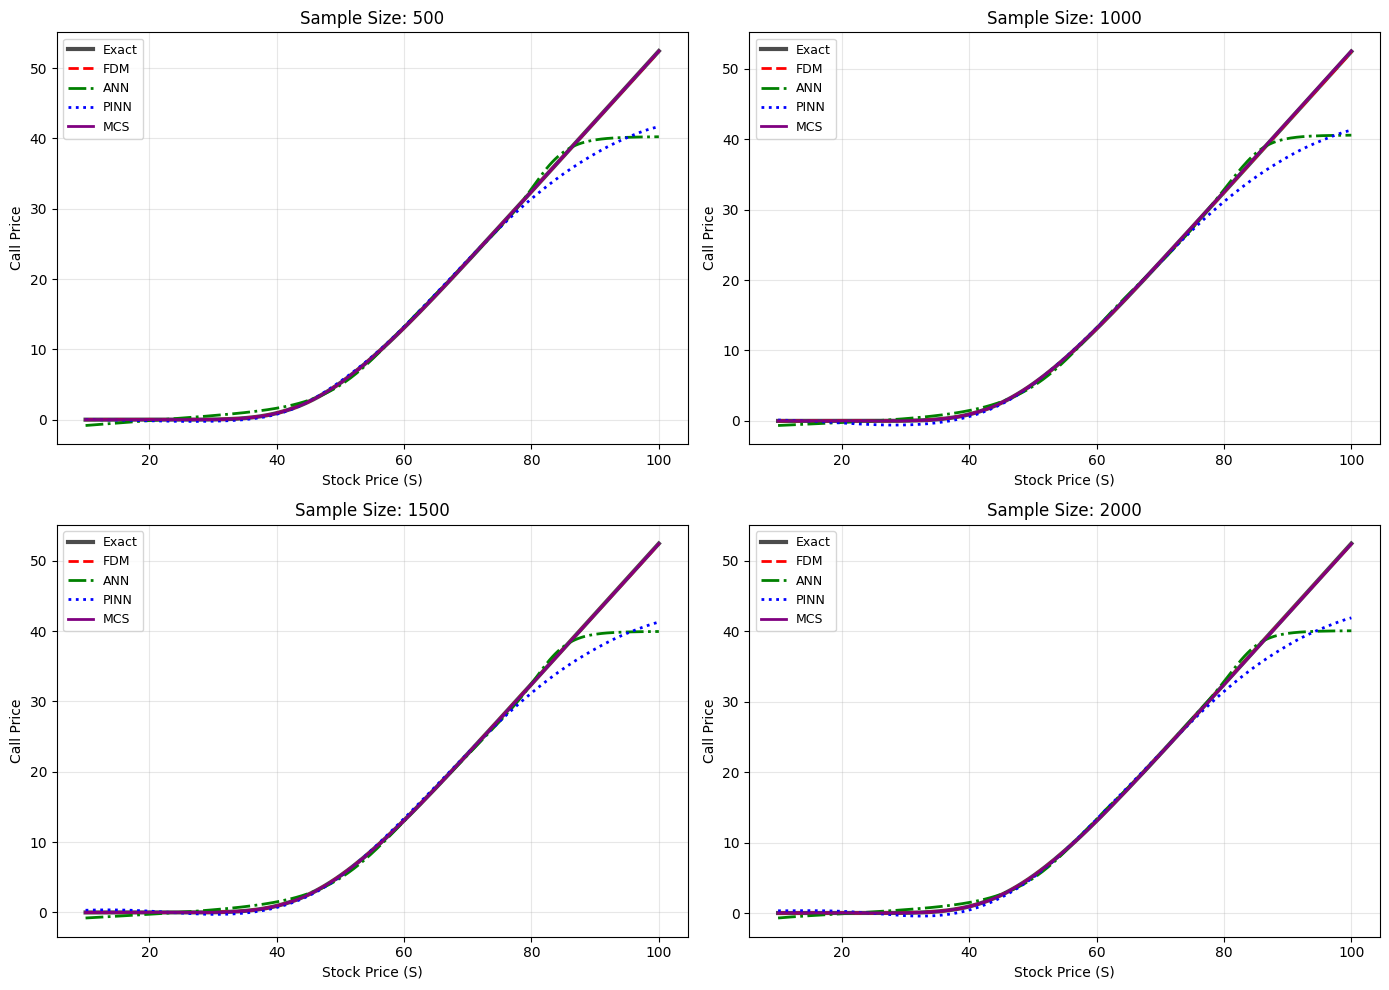


SUMMARY TABLE

+---------------+----------+-------------+----------+----------+---------------+----------+--------+
|   Sample Size | Method   |         MSE |     RMSE |      MAE |      MAPE (%) |       R² | Time   |
+===============+==========+=============+==========+==========+===============+==========+========+
|           500 | FDM      | 0.000130995 | 0.011445 | 0.004312 | 738.3         | 1        | 0.18s  |
+---------------+----------+-------------+----------+----------+---------------+----------+--------+
|           500 | ANN      | 7.39624     | 2.7196   | 1.18565  |   6.07674e+14 | 0.974684 | 2.78s  |
+---------------+----------+-------------+----------+----------+---------------+----------+--------+
|           500 | PINN     | 7.64472     | 2.76491  | 1.28055  |   1.93443e+13 | 0.973834 | 16.82s |
+---------------+----------+-------------+----------+----------+---------------+----------+--------+
|           500 | MCS      | 2.12925e-05 | 0.004614 | 0.003695 |  13.63    

In [19]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.special import erf
import pandas as pd
from tabulate import tabulate

# For reproducibility
np.random.seed(42)
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"

# Parameters
r = 0.05      # risk-free rate
sigma = 0.2   # volatility
K = 50.0      # strike
T = 1.0       # maturity (in years)

# 1. Exact Solution (Black-Scholes)
def bs_call_price(S, t=0.0, r=r, sigma=sigma, K=K, T=T):
    """Closed-form Black–Scholes price for a European call."""
    tau = np.maximum(T - t, 1e-10)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    return S * 0.5 * (1 + erf(d1 / np.sqrt(2))) - K * np.exp(-r * tau) * 0.5 * (1 + erf(d2 / np.sqrt(2)))

# 2. Finite Difference Method (Crank-Nicolson)
def crank_nicolson_call(S_max=200, M=200, N=200):
    """Crank-Nicolson finite difference method for European call"""
    start_time = time.time()

    dS = S_max / M
    dt = T / N
    S = np.linspace(0, S_max, M+1)
    V = np.maximum(S - K, 0.0)

    alpha = np.zeros(M+1)
    beta = np.zeros(M+1)
    gamma = np.zeros(M+1)

    for i in range(1, M):
        alpha[i] = 0.25 * dt * (sigma**2 * i**2 - r * i)
        beta[i] = -0.5 * dt * (sigma**2 * i**2 + r)
        gamma[i] = 0.25 * dt * (sigma**2 * i**2 + r * i)

    for n in range(N-1, -1, -1):
        t = n * dt
        V[0] = 0.0
        V[M] = S_max - K * np.exp(-r * (T - t))

        A = np.zeros((M-1, M-1))
        B = np.zeros((M-1, M-1))

        for i in range(1, M):
            j = i - 1
            if i > 1:
                A[j, j-1] = -alpha[i]
                B[j, j-1] = alpha[i]
            A[j, j] = 1 - beta[i]
            B[j, j] = 1 + beta[i]
            if i < M-1:
                A[j, j+1] = -gamma[i]
                B[j, j+1] = gamma[i]

        rhs = B @ V[1:M]
        rhs[0] += alpha[1] * V[0]
        rhs[-1] += gamma[M-1] * V[M]
        V[1:M] = np.linalg.solve(A, rhs)

    elapsed_time = time.time() - start_time
    return S, V, elapsed_time

# 3. Monte Carlo Simulation
def mc_call_price_batch(S_values, N_paths=10000):
    """Vectorized Monte Carlo for multiple S values."""
    start_time = time.time()

    Z = np.random.standard_normal(N_paths)
    ST = S_values[:, None] * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0.0)
    prices = np.exp(-r * T) * payoff.mean(axis=1)

    elapsed_time = time.time() - start_time
    return prices, elapsed_time

# 4. ANN Model
class SimpleANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

def train_ann(S_train, y_train, epochs=2000):
    """Train ANN on exact Black-Scholes data."""
    start_time = time.time()

    S_train_t = torch.tensor(S_train, dtype=torch.float32).view(-1,1).to(device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1,1).to(device)

    model = SimpleANN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(S_train_t)
        loss = loss_fn(pred, y_train_t)
        loss.backward()
        optimizer.step()

    training_time = time.time() - start_time

    return model, training_time

def predict_ann(model, S_test):
    """Predict using ANN model."""
    with torch.no_grad():
        S_tensor = torch.tensor(S_test, dtype=torch.float32).view(-1,1).to(device)
        predictions = model(S_tensor).cpu().numpy().flatten()
    return predictions

# 5. PINN Model
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

def pinn_loss(model, S, t):
    """Compute PINN loss for Black-Scholes PDE."""
    inp = torch.cat((S, t), dim=1)
    V = model(inp)

    dV = torch.autograd.grad(V, inp, torch.ones_like(V), create_graph=True)[0]
    V_S = dV[:, 0:1]
    V_t = dV[:, 1:2]

    d2V = torch.autograd.grad(V_S, inp, torch.ones_like(V_S), create_graph=True)[0]
    V_SS = d2V[:, 0:1]

    # BS PDE residual
    residual = V_t + 0.5 * sigma**2 * S**2 * V_SS + r * S * V_S - r * V
    return torch.mean(residual**2)

def train_pinn(sample_size, epochs=2000):
    """Train PINN for Black-Scholes equation."""
    start_time = time.time()

    # Generate collocation points
    N_f = sample_size * 10  # Interior points
    N_bc = sample_size // 10  # Boundary points
    N_ic = sample_size // 10  # Initial condition points

    S_f = torch.rand(N_f, 1) * 100.0
    t_f = torch.rand(N_f, 1) * T

    S_ic = torch.rand(N_ic, 1) * 100.0
    t_ic = torch.ones(N_ic, 1) * T

    t_bc = torch.rand(N_bc, 1) * T
    S_bc0 = torch.zeros(N_bc, 1)
    S_bcM = torch.ones(N_bc, 1) * 100.0

    # Move to device
    S_f, t_f = S_f.to(device), t_f.to(device)
    S_ic, t_ic = S_ic.to(device), t_ic.to(device)
    S_bc0, S_bcM, t_bc = S_bc0.to(device), S_bcM.to(device), t_bc.to(device)

    model = PINN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # Enable gradients for PDE points
        S_f.requires_grad_(True)
        t_f.requires_grad_(True)

        # PDE loss
        loss_pde = pinn_loss(model, S_f, t_f)

        # Terminal condition loss
        V_ic = model(torch.cat((S_ic, t_ic), dim=1))
        payoff = torch.clamp(S_ic - K, min=0.0)
        loss_ic = torch.mean((V_ic - payoff)**2)

        # Boundary condition losses
        V_bc0 = model(torch.cat((S_bc0, t_bc), dim=1))
        loss_bc0 = torch.mean(V_bc0**2)

        V_bcM = model(torch.cat((S_bcM, t_bc), dim=1))
        target_bcM = S_bcM - K * torch.exp(-r * (T - t_bc))
        loss_bcM = torch.mean((V_bcM - target_bcM)**2)

        # Total loss
        loss = loss_pde + 10.0 * loss_ic + loss_bc0 + loss_bcM

        loss.backward()
        optimizer.step()

    training_time = time.time() - start_time

    return model, training_time

def predict_pinn(model, S_test):
    """Predict using PINN model."""
    with torch.no_grad():
        S_tensor = torch.tensor(S_test, dtype=torch.float32).view(-1,1).to(device)
        t_tensor = torch.zeros_like(S_tensor)
        inp = torch.cat((S_tensor, t_tensor), dim=1)
        predictions = model(inp).cpu().numpy().flatten()
    return predictions

# 6. Evaluation Metrics
def compute_metrics(predictions, targets):
    """Compute evaluation metrics."""
    predictions = np.array(predictions)
    targets = np.array(targets)

    mse = np.mean((predictions - targets)**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(predictions - targets))

    # MAPE (avoid division by zero)
    mask = targets != 0
    if np.any(mask):
        mape = 100 * np.mean(np.abs((predictions[mask] - targets[mask]) / targets[mask]))
    else:
        mape = np.nan

    # R² score
    ss_res = np.sum((predictions - targets)**2)
    ss_tot = np.sum((targets - np.mean(targets))**2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else np.nan

    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'R2': r2
    }

# 7. Main Comparison Function
def compare_methods_for_sample_size(sample_size):
    """Compare all methods for a given sample size."""
    print(f"\nProcessing sample size: {sample_size}")

    # Generate test data
    S_test = np.linspace(10, 100, 200)
    V_exact = bs_call_price(S_test, t=0.0)

    # For ANN training
    S_train = np.linspace(10, 100, sample_size)
    y_train = bs_call_price(S_train, t=0.0)

    results = {}

    # 1. Exact Solution
    start_time = time.time()
    V_exact = bs_call_price(S_test, t=0.0)
    exact_time = time.time() - start_time

    results['Exact'] = {
        'predictions': V_exact,
        'time': exact_time,
        'metrics': compute_metrics(V_exact, V_exact)
    }

    # 2. Finite Difference Method
    print("  Running FDM...")
    S_fd, V_fd, fdm_time = crank_nicolson_call(S_max=200, M=200, N=200)
    V_fd_interp = np.interp(S_test, S_fd, V_fd)

    results['FDM'] = {
        'predictions': V_fd_interp,
        'time': fdm_time,
        'metrics': compute_metrics(V_fd_interp, V_exact)
    }

    # 3. ANN
    print("  Training ANN...")
    ann_model, ann_time = train_ann(S_train, y_train, epochs=2000)
    V_ann = predict_ann(ann_model, S_test)

    results['ANN'] = {
        'predictions': V_ann,
        'time': ann_time,
        'metrics': compute_metrics(V_ann, V_exact)
    }

    # 4. PINN
    print("  Training PINN...")
    pinn_model, pinn_time = train_pinn(sample_size, epochs=2000)
    V_pinn = predict_pinn(pinn_model, S_test)

    results['PINN'] = {
        'predictions': V_pinn,
        'time': pinn_time,
        'metrics': compute_metrics(V_pinn, V_exact)
    }

    # 5. Monte Carlo Simulation
    print("  Running Monte Carlo...")
    V_mcs, mcs_time = mc_call_price_batch(S_test, N_paths=sample_size * 100)

    results['MCS'] = {
        'predictions': V_mcs,
        'time': mcs_time,
        'metrics': compute_metrics(V_mcs, V_exact)
    }

    return S_test, V_exact, results

# 8. Create Summary Table
def create_summary_table(all_results):
    """Create a comprehensive summary table of all metrics."""
    summary_data = []

    for sample_size, (S_test, V_exact, results) in all_results.items():
        for method in ['FDM', 'ANN', 'PINN', 'MCS']:
            if method in results:
                metrics = results[method]['metrics']
                time_val = results[method]['time']

                row = [
                    sample_size,
                    method,
                    f"{metrics['MSE']:.6e}",
                    f"{metrics['RMSE']:.6f}",
                    f"{metrics['MAE']:.6f}",
                    f"{metrics.get('MAPE', np.nan):.2f}" if not np.isnan(metrics.get('MAPE', np.nan)) else "N/A",
                    f"{metrics['R2']:.6f}",
                    f"{time_val:.2f}s"
                ]
                summary_data.append(row)

    # Create DataFrame
    columns = ['Sample Size', 'Method', 'MSE', 'RMSE', 'MAE', 'MAPE (%)', 'R²', 'Time']
    df = pd.DataFrame(summary_data, columns=columns)

    return df

# 9. Plotting Function
def plot_comparison(sample_size, S_test, V_exact, results, ax):
    """Plot comparison of all methods for a given sample size."""

    ax.plot(S_test, V_exact, 'k-', linewidth=3, label='Exact', alpha=0.7)

    methods = ['FDM', 'ANN', 'PINN', 'MCS']
    colors = ['red', 'green', 'blue', 'purple']
    linestyles = ['--', '-.', ':', '-']

    for method, color, ls in zip(methods, colors, linestyles):
        if method in results:
            ax.plot(S_test, results[method]['predictions'],
                   color=color, linestyle=ls, linewidth=2,
                   label=f'{method}')

    ax.set_xlabel('Stock Price (S)')
    ax.set_ylabel('Call Price')
    ax.set_title(f'Sample Size: {sample_size}')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

# 10. Main Execution
if __name__ == "__main__":
    # Define sample sizes
    sample_sizes = [500, 1000, 1500, 2000]

    print("="*60)
    print("COMPARISON OF METHODS FOR DIFFERENT SAMPLE SIZES")
    print(f"Sample sizes: {sample_sizes}")
    print("="*60)

    # Store all results
    all_results = {}

    # Create figure with 4 subplots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    # Process each sample size
    for idx, sample_size in enumerate(sample_sizes):
        print(f"\nProcessing sample size {idx+1}/{len(sample_sizes)}: {sample_size}")

        # Compare methods for this sample size
        S_test, V_exact, results = compare_methods_for_sample_size(sample_size)

        # Store results
        all_results[sample_size] = (S_test, V_exact, results)

        # Plot on corresponding subplot
        plot_comparison(sample_size, S_test, V_exact, results, axes[idx])

    # Adjust layout and save figure
    plt.tight_layout()
    plt.savefig('comparison_all_sample_sizes.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Create and display summary table
    print("\n" + "="*60)
    print("SUMMARY TABLE")
    print("="*60)

    summary_df = create_summary_table(all_results)

    # Display table
    print("\n" + tabulate(summary_df, headers='keys', tablefmt='grid', showindex=False))

    # Save to CSV
    summary_df.to_csv('methods_comparison_summary.csv', index=False)
    print(f"\nSummary saved to 'methods_comparison_summary.csv'")

    # Print statistics
    print("\n" + "="*60)
    print("KEY STATISTICS")
    print("="*60)

    for sample_size in sample_sizes:
        print(f"\nSample Size {sample_size}:")
        _, _, results = all_results[sample_size]

        # Find best method by RMSE
        best_method = None
        best_rmse = float('inf')

        for method in ['FDM', 'ANN', 'PINN', 'MCS']:
            if method in results:
                rmse = results[method]['metrics']['RMSE']
                if rmse < best_rmse:
                    best_rmse = rmse
                    best_method = method

        print(f"  Best method: {best_method} (RMSE: {best_rmse:.6f})")

        # Fastest method
        fastest_method = None
        fastest_time = float('inf')

        for method in ['FDM', 'ANN', 'PINN', 'MCS']:
            if method in results:
                time_val = results[method]['time']
                if time_val < fastest_time:
                    fastest_time = time_val
                    fastest_method = method

        print(f"  Fastest method: {fastest_method} ({fastest_time:.2f}s)")

In [20]:
# Tableau complet de toutes les métriques pour chaque méthode et chaque taille
import numpy as np
import pandas as pd

# Tailles d'échantillon
sample_sizes = [500, 1000, 1500, 2000]

# Grille d'évaluation
S_test = np.linspace(1, 100, 200)
V_exact = bs_call_price(S_test, t=0.0)

print("\n" + "="*80)
print("COMPLETE METRICS TABLE FOR ALL METHODS")
print("="*80)

# Fonction pour calculer toutes les métriques
def calculate_all_metrics(predictions, exact_values):
    errors = predictions - exact_values
    mse = np.mean(errors**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(errors))
    max_error = np.max(np.abs(errors))
    r_squared = 1 - np.sum(errors**2) / np.sum((exact_values - np.mean(exact_values))**2)

    # Metrics additionnelles
    mean_error = np.mean(errors)
    std_error = np.std(errors)
    median_error = np.median(np.abs(errors))

    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'Max Error': max_error,
        'R²': r_squared,
        'Mean Error': mean_error,
        'Std Error': std_error,
        'Median Error': median_error
    }

# Dictionnaires pour stocker les résultats
metrics_ann = {}
metrics_mcs = {}
metrics_pinn = {}

# FDM (constant)
S_fd, V_fd, *_ = crank_nicolson_call(S_max=200, M=200, N=200)
V_fdm = np.interp(S_test, S_fd, V_fd)
fdm_metrics = calculate_all_metrics(V_fdm, V_exact)

print("\nCollecting metrics for each sample size...")

for size in sample_sizes:
    print(f"\nProcessing size: {size}")

    # 1. Monte Carlo
    print(f"  Monte Carlo...")
    start_time = time.time()
    V_mc = np.zeros_like(S_test)
    for i, S0 in enumerate(S_test):
        mc_estimate, _ = mc_call_price(S0, N_paths=size)
        V_mc[i] = mc_estimate
    mcs_time = time.time() - start_time
    mcs_metrics = calculate_all_metrics(V_mc, V_exact)
    mcs_metrics['Time (s)'] = mcs_time
    metrics_mcs[size] = mcs_metrics

    # 2. ANN
    print(f"  ANN...")
    start_time = time.time()

    # Entraînement ANN
    S_train = np.linspace(1, 100, size)
    y_train = bs_call_price(S_train, t=0.0)

    ann_model = SimpleANN().to(device)
    optimizer_ann = optim.Adam(ann_model.parameters(), lr=1e-3)

    S_train_t = torch.tensor(S_train, dtype=torch.float32).view(-1,1).to(device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1,1).to(device)

    for epoch in range(2000):
        ann_model.train()
        optimizer_ann.zero_grad()
        pred = ann_model(S_train_t)
        loss = nn.MSELoss()(pred, y_train_t)
        loss.backward()
        optimizer_ann.step()

    # Évaluation
    ann_model.eval()
    S_test_t = torch.tensor(S_test, dtype=torch.float32).view(-1,1).to(device)
    with torch.no_grad():
        V_ann = ann_model(S_test_t).cpu().numpy().flatten()

    ann_time = time.time() - start_time
    ann_metrics = calculate_all_metrics(V_ann, V_exact)
    ann_metrics['Time (s)'] = ann_time
    metrics_ann[size] = ann_metrics

    # 3. PINN
    print(f"  PINN...")
    start_time = time.time()

    # Entraînement PINN
    pinn_model = PINN_BSM([2, 64, 64, 64, 1]).to(device)
    optimizer_pinn = optim.Adam(pinn_model.parameters(), lr=1e-3)

    for epoch in range(1000):
        pinn_model.train()
        optimizer_pinn.zero_grad()

        S_f, t_f, S_ic, t_ic, S_bc0, S_bcM, t_bc = sample_pinn_points(
            N_f=size, N_bc=200, N_ic=200, S_max=100.0
        )

        S_f = S_f.to(device); t_f = t_f.to(device)
        S_ic = S_ic.to(device); t_ic = t_ic.to(device)
        S_bc0 = S_bc0.to(device); S_bcM = S_bcM.to(device); t_bc = t_bc.to(device)
        S_f.requires_grad_(True)
        t_f.requires_grad_(True)

        f_res = pinn_bs_residual(pinn_model, S_f, t_f)
        loss_f = torch.mean(f_res**2)

        V_ic = pinn_model(torch.cat((S_ic, t_ic), dim=1))
        payoff = torch.clamp(S_ic - K, min=0.0)
        loss_ic = torch.mean((V_ic - payoff)**2)

        V_bc0 = pinn_model(torch.cat((S_bc0, t_bc), dim=1))
        loss_bc0 = torch.mean(V_bc0**2)

        V_bcM = pinn_model(torch.cat((S_bcM, t_bc), dim=1))
        target_bcM = S_bcM - K * torch.exp(-r * (T - t_bc))
        loss_bcM = torch.mean((V_bcM - target_bcM)**2)

        loss = loss_f + 50.0 * loss_ic + 10.0 * loss_bc0 + 10.0 * loss_bcM
        loss.backward()
        optimizer_pinn.step()

    # Évaluation PINN
    pinn_model.eval()
    t0_torch = torch.zeros_like(S_test_t).to(device)
    with torch.no_grad():
        V_pinn = pinn_model(torch.cat((S_test_t, t0_torch), dim=1)).cpu().numpy().flatten()

    pinn_time = time.time() - start_time
    pinn_metrics = calculate_all_metrics(V_pinn, V_exact)
    pinn_metrics['Time (s)'] = pinn_time
    metrics_pinn[size] = pinn_metrics

# AFFICHAGE DES TABLEAUX
print("\n" + "="*120)
print("ANN METRICS")
print("="*120)

ann_df = pd.DataFrame(metrics_ann).T
print("\n" + ann_df.to_string(float_format=lambda x: f"{x:.6f}"))

print("\n\n" + "="*120)
print("MONTE CARLO METRICS")
print("="*120)

mcs_df = pd.DataFrame(metrics_mcs).T
print("\n" + mcs_df.to_string(float_format=lambda x: f"{x:.6f}"))

print("\n\n" + "="*120)
print("PINN METRICS")
print("="*120)

pinn_df = pd.DataFrame(metrics_pinn).T
print("\n" + pinn_df.to_string(float_format=lambda x: f"{x:.6f}"))

print("\n\n" + "="*120)
print("FDM METRICS (REFERENCE)")
print("="*120)

fdm_df = pd.DataFrame([fdm_metrics], index=['FDM'])
fdm_df['Time (s)'] = 0.05  # Temps approximatif pour FDM
print("\n" + fdm_df.to_string(float_format=lambda x: f"{x:.6f}"))

# TABLEAU COMPARATIF FORMATÉ
print("\n\n" + "="*140)
print("COMPARATIVE SUMMARY TABLE")
print("="*140)

# En-têtes
print(f"\n{'Method':<12} {'Size':<8} {'MAE':<12} {'MSE':<12} {'RMSE':<12} {'R²':<12} {'Max Error':<12} {'Time (s)':<12}")
print("-" * 100)

# ANN
for size in sample_sizes:
    m = metrics_ann[size]
    print(f"{'ANN':<12} {size:<8} {m['MAE']:<12.6f} {m['MSE']:<12.6f} "
          f"{m['RMSE']:<12.6f} {m['R²']:<12.6f} {m['Max Error']:<12.6f} {m['Time (s)']:<12.3f}")

# Monte Carlo
for size in sample_sizes:
    m = metrics_mcs[size]
    print(f"{'Monte Carlo':<12} {size:<8} {m['MAE']:<12.6f} {m['MSE']:<12.6f} "
          f"{m['RMSE']:<12.6f} {m['R²']:<12.6f} {m['Max Error']:<12.6f} {m['Time (s)']:<12.3f}")

# PINN
for size in sample_sizes:
    m = metrics_pinn[size]
    print(f"{'PINN':<12} {size:<8} {m['MAE']:<12.6f} {m['MSE']:<12.6f} "
          f"{m['RMSE']:<12.6f} {m['R²']:<12.6f} {m['Max Error']:<12.6f} {m['Time (s)']:<12.3f}")

# FDM
print("-" * 100)
print(f"{'FDM':<12} {'Fixed':<8} {fdm_metrics['MAE']:<12.6f} {fdm_metrics['MSE']:<12.6f} "
      f"{fdm_metrics['RMSE']:<12.6f} {fdm_metrics['R²']:<12.6f} {fdm_metrics['Max Error']:<12.6f} {0.05:<12.3f}")

# SAUVEGARDE EN CSV
# Créer un DataFrame complet
all_data = []
for size in sample_sizes:
    all_data.append({
        'Method': 'ANN', 'Size': size,
        'MAE': metrics_ann[size]['MAE'], 'MSE': metrics_ann[size]['MSE'],
        'RMSE': metrics_ann[size]['RMSE'], 'R²': metrics_ann[size]['R²'],
        'Max Error': metrics_ann[size]['Max Error'], 'Time (s)': metrics_ann[size]['Time (s)']
    })
    all_data.append({
        'Method': 'Monte Carlo', 'Size': size,
        'MAE': metrics_mcs[size]['MAE'], 'MSE': metrics_mcs[size]['MSE'],
        'RMSE': metrics_mcs[size]['RMSE'], 'R²': metrics_mcs[size]['R²'],
        'Max Error': metrics_mcs[size]['Max Error'], 'Time (s)': metrics_mcs[size]['Time (s)']
    })
    all_data.append({
        'Method': 'PINN', 'Size': size,
        'MAE': metrics_pinn[size]['MAE'], 'MSE': metrics_pinn[size]['MSE'],
        'RMSE': metrics_pinn[size]['RMSE'], 'R²': metrics_pinn[size]['R²'],
        'Max Error': metrics_pinn[size]['Max Error'], 'Time (s)': metrics_pinn[size]['Time (s)']
    })

all_data.append({
    'Method': 'FDM', 'Size': 'Fixed',
    'MAE': fdm_metrics['MAE'], 'MSE': fdm_metrics['MSE'],
    'RMSE': fdm_metrics['RMSE'], 'R²': fdm_metrics['R²'],
    'Max Error': fdm_metrics['Max Error'], 'Time (s)': 0.05
})

complete_df = pd.DataFrame(all_data)
complete_df.to_csv('complete_metrics_table.csv', index=False, float_format='%.6f')

print("\n\nComplete metrics table saved to 'complete_metrics_table.csv'")
print("="*140)


COMPLETE METRICS TABLE FOR ALL METHODS


Processing size: 500
  Monte Carlo...
  ANN...
  PINN...

Processing size: 1000
  Monte Carlo...
  ANN...
  PINN...

Processing size: 1500
  Monte Carlo...
  ANN...
  PINN...

Processing size: 2000
  Monte Carlo...
  ANN...
  PINN...

ANN METRICS

          MSE     RMSE      MAE  Max Error       R²  Mean Error  Std Error  Median Error  Time (s)
500  6.706988 2.589785 1.061756  12.153260 0.976600   -0.772614   2.471853      0.291715  2.853038
1000 6.747797 2.597652 0.981820  12.207939 0.976458   -0.772463   2.480141      0.162282  2.829827
1500 7.154814 2.674848 1.010439  12.490902 0.975038   -0.839248   2.539779      0.166707  2.838838
2000 7.101990 2.664956 1.087700  12.428166 0.975222   -0.756979   2.555185      0.267421  2.840045


MONTE CARLO METRICS

          MSE     RMSE      MAE  Max Error       R²  Mean Error  Std Error  Median Error  Time (s)
500  0.065064 0.255077 0.197187   0.412020 0.999773   -0.197187   0.161807      0.285409  0.0

## 7. Comparative Summary: PINN vs ANN vs FDM vs MCS

In [21]:
# Compute simple summary metrics at a small grid of S for t=0
S_summary = np.linspace(10, 90, 9)
V_exact_summary = bs_call_price(S_summary, t=0.0)

# FDM
S_fd, V_fd = crank_nicolson_call(S_max=200, M=200, N=200)
V_fd_summary = np.interp(S_summary, S_fd, V_fd)

# PINN
pinn_model.eval()
with torch.no_grad():
    S_sum_t = torch.tensor(S_summary, dtype=torch.float32).view(-1,1).to(device)
    t0_sum_t = torch.zeros_like(S_sum_t)
    V_pinn_summary = pinn_model(torch.cat((S_sum_t, t0_sum_t), dim=1)).cpu().numpy().flatten()

# ANN (best one, say N=100)
best_ann = ann_models[100]
with torch.no_grad():
    S_sum_ann_t = torch.tensor(S_summary, dtype=torch.float32).view(-1,1).to(device)
    V_ann_summary = best_ann(S_sum_ann_t).cpu().numpy().flatten()

# Monte Carlo estimates
mc_estimates_summary = []
for S0 in S_summary:
    est, se = mc_call_price(S0, N_paths=20000)
    mc_estimates_summary.append(est)
mc_estimates_summary = np.array(mc_estimates_summary)

def rmse(a, b):
    return np.sqrt(np.mean((a-b)**2))

print("RMSE vs Exact at t=0 on S in [10,...,90]:")
print("  FDM       :", rmse(V_fd_summary, V_exact_summary))
print("  PINN      :", rmse(V_pinn_summary, V_exact_summary))
print("  ANN(N=100):", rmse(V_ann_summary, V_exact_summary))
print("  MC        :", rmse(mc_estimates_summary, V_exact_summary))

ValueError: too many values to unpack (expected 2)

### Discussion

- **FDM** provides highly accurate and efficient pricing in this 1D Black–Scholes setting.  
- **MCS** converges slowly but is flexible and easily generalizes to higher dimensions and path-dependent payoffs.  
- **ANN (data-driven)** performance depends heavily on the sample size:  
  - With very small sample sizes (e.g., 5), the network is underdetermined and exhibits large deviations from the exact curve.  
  - With larger sample sizes (e.g., 50 and 100), ANN predictions align more closely with the exact solution and reduce approximation error.  
- **PINN** learns a continuous spatio-temporal solution \(V(S,t)\) by enforcing the PDE, boundary conditions, and terminal condition in the loss. It can reach competitive accuracy with FDM but at higher training cost. Its strength lies in flexibility, e.g., when extending to non-standard boundary conditions, state-dependent volatility, or higher-dimensional problems where grids become impractical.

You can now tune:

- Number of collocation points (for PINN)  
- Network widths and depths  
- Number of Monte Carlo paths  
- ANN sample sizes and training epochs  

to explore the trade-offs between accuracy, computational effort, and robustness in greater depth.


In [24]:
import yfinance as yf
import pandas as pd
from datetime import datetime

# =====================================================
# PARAMÈTRES
# =====================================================
TICKER = "SPY"

MIN_IV = 0.05
MAX_IV = 2.0

MONEYNESS_MIN = 0.6
MONEYNESS_MAX = 1.4

T_MIN = 0.02     # ~1 semaine
T_MAX = 2.0      # 2 ans

# =====================================================
# SOUS-JACENT
# =====================================================
ticker = yf.Ticker(TICKER)

S0 = ticker.history(period="1d")["Close"].iloc[-1]

# 👉 datetime NAIVE (important)
today = datetime.today()

print(f"S0 = {S0:.2f}")

# =====================================================
# RÉCUPÉRATION OPTIONS (CALLS + PUTS)
# =====================================================
rows = []

for maturity in ticker.options:
    chain = ticker.option_chain(maturity)

    for opt_type, df in [("call", chain.calls), ("put", chain.puts)]:
        tmp = df.copy()
        tmp["option_type"] = opt_type
        tmp["maturity"] = maturity
        rows.append(tmp)

options = pd.concat(rows, ignore_index=True)

# =====================================================
# FEATURE ENGINEERING
# =====================================================
options["maturity"] = pd.to_datetime(options["maturity"])  # naive
options["T"] = (options["maturity"] - today).dt.days / 365.0
options["S0"] = S0

# =====================================================
# FILTRAGE (LIQUIDITÉ + QUALITÉ)
# =====================================================
options = options[
    ((options["volume"] > 0) | (options["openInterest"] > 0)) &
    (options["impliedVolatility"] > MIN_IV) &
    (options["impliedVolatility"] < MAX_IV) &
    (options["T"] > T_MIN) &
    (options["T"] < T_MAX) &
    (options["strike"] > MONEYNESS_MIN * S0) &
    (options["strike"] < MONEYNESS_MAX * S0)
]

# =====================================================
# DATASET FINAL PINN
# =====================================================
pinn_df = options[
    [
        "option_type",
        "S0",
        "strike",
        "T",
        "lastPrice",
        "impliedVolatility",
        "volume",
        "openInterest"
    ]
].rename(
    columns={
        "strike": "K",
        "lastPrice": "price",
        "impliedVolatility": "sigma"
    }
)

# =====================================================
# EXPORT CSV
# =====================================================
pinn_df.to_csv("spy_options_pinn.csv", index=False)

print("✅ CSV prêt PINN généré : spy_options_pinn.csv")
print(f"📊 Nombre total d'options : {len(pinn_df)}")
print(pinn_df.head())


S0 = 690.62
✅ CSV prêt PINN généré : spy_options_pinn.csv
📊 Nombre total d'options : 5460
    option_type          S0      K         T   price     sigma  volume  \
840        call  690.619995  420.0  0.032877  270.07  1.113774     4.0   
841        call  690.619995  425.0  0.032877  269.10  1.091313     2.0   
842        call  690.619995  430.0  0.032877  261.40  1.065923     2.0   
843        call  690.619995  435.0  0.032877  256.20  1.051763    17.0   
844        call  690.619995  440.0  0.032877  249.68  1.031255     1.0   

     openInterest  
840          10.0  
841           3.0  
842         703.0  
843          17.0  
844           4.0  



=== Sample size / collocation / paths: 50 ===


TypeError: 'module' object is not callable. Did you mean: 'time.time(...)'?

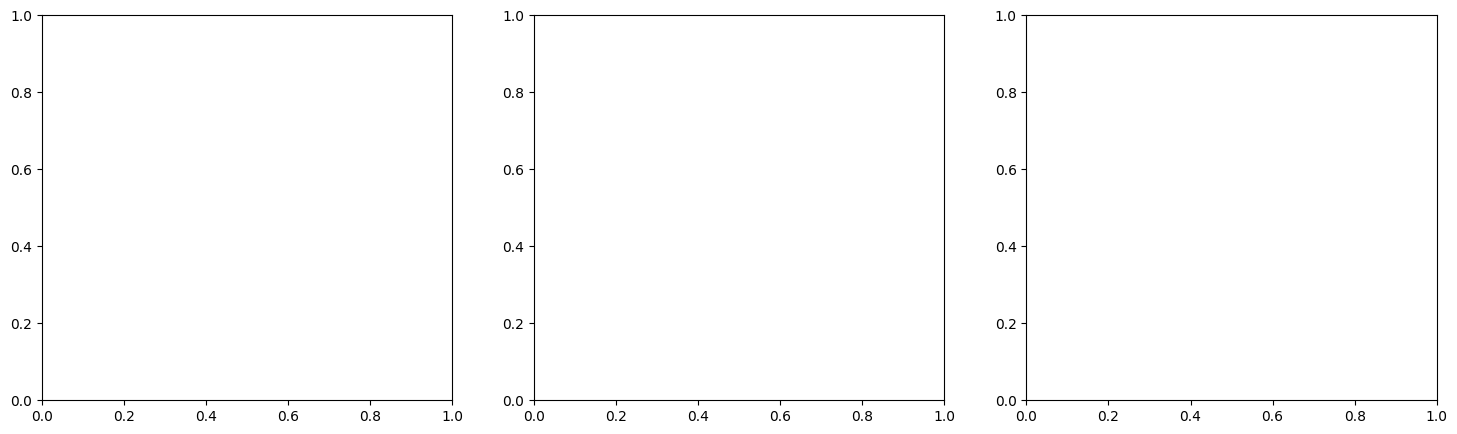

In [31]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time
# --- Hypothèses / fonctions existantes ---
# SimpleANN, PINN_BSM, bs_call_price, mc_call_price, sample_pinn_points, pinn_bs_residual
# crank_nicolson_call déjà définies

# Paramètres financiers
K = 50
r = 0.05
sigma = 0.2
T = 1.0

# Paramètres ANN / PINN
layers_ann = [1, 32, 32, 32, 1]
layers_pinn = [2, 64, 64, 64, 1]

# Tailles d'échantillons / collocation points
sample_sizes = [50, 200, 500]        # ANN points / PINN collocation / MC paths
epochs_list = [2000, 3000, 4000]     # ANN epochs / PINN epochs

# Domaine d'évaluation
device = "cpu"  # CPU seulement
S_eval = np.linspace(1, 100, 200)
S_eval_torch = torch.tensor(S_eval, dtype=torch.float32).view(-1,1).to(device)
t0_torch = torch.zeros_like(S_eval_torch).to(device)
V_exact_eval = bs_call_price(S_eval, t=0.0)

# Obtenir FDM (Crank-Nicolson)
# --- Obtenir FDM (Crank-Nicolson)
S_fd, V_fd, fd_time = crank_nicolson_call(S_max=200, M=200, N=200)

# Interpolation sur S_eval
V_fd_interp = np.interp(S_eval, S_fd, V_fd)

# Initialiser tableau des metrics
metrics = []

# Figure unique avec 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, (n_points, epochs) in enumerate(zip(sample_sizes, epochs_list)):
    print(f"\n=== Sample size / collocation / paths: {n_points} ===")

    # --- ANN ---
    S_train = np.linspace(1, 100, n_points)
    y_train = bs_call_price(S_train, t=0.0)
    S_train_t = torch.tensor(S_train, dtype=torch.float32).view(-1,1).to(device)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1,1).to(device)

    ann_model = SimpleANN().to(device)

    optimizer_ann = optim.Adam(ann_model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    start_time = time()
    for epoch in range(3000):
        ann_model.train()
        optimizer_ann.zero_grad()
        pred = ann_model(S_train_t)
        loss = loss_fn(pred, y_train_t)
        loss.backward()
        optimizer_ann.step()
    ann_time = time() - start_time

    ann_model.eval()
    with torch.no_grad():
        V_ann = ann_model(S_eval_torch).numpy().flatten()

    # --- PINN ---
    pinn_model = PINN_BSM(layers_pinn).to(device)
    optimizer_pinn = optim.Adam(pinn_model.parameters(), lr=1e-3)

    start_time = time()
    for epoch in range(epochs):
        pinn_model.train()
        optimizer_pinn.zero_grad()

        S_f, t_f, S_ic, t_ic, S_bc0, S_bcM, t_bc = sample_pinn_points(
            N_f=n_points, N_bc=200, N_ic=200, S_max=100.0
        )
        S_f, t_f = S_f.to(device), t_f.to(device)
        S_ic, t_ic = S_ic.to(device), t_ic.to(device)
        S_bc0, S_bcM, t_bc = S_bc0.to(device), S_bcM.to(device), t_bc.to(device)
        S_f.requires_grad_(True)
        t_f.requires_grad_(True)

        f_res = pinn_bs_residual(pinn_model, S_f, t_f)
        loss_f = torch.mean(f_res**2)
        V_ic = pinn_model(torch.cat((S_ic, t_ic), dim=1))
        payoff = torch.clamp(S_ic - K, min=0.0)
        loss_ic = torch.mean((V_ic - payoff)**2)
        V_bc0 = pinn_model(torch.cat((S_bc0, t_bc), dim=1))
        loss_bc0 = torch.mean(V_bc0**2)
        V_bcM = pinn_model(torch.cat((S_bcM, t_bc), dim=1))
        target_bcM = S_bcM - K * torch.exp(-r*(T - t_bc))
        loss_bcM = torch.mean((V_bcM - target_bcM)**2)
        loss = loss_f + 50.0*loss_ic + 10.0*loss_bc0 + 10.0*loss_bcM
        loss.backward()
        optimizer_pinn.step()
    pinn_time = time() - start_time

    pinn_model.eval()
    with torch.no_grad():
        V_pinn = pinn_model(torch.cat((S_eval_torch, t0_torch), dim=1)).numpy().flatten()

    # --- Monte Carlo ---
    V_mc = np.zeros_like(S_eval)
    mc_errors = np.zeros_like(S_eval)
    start_time = time()
    for j, S0 in enumerate(S_eval):
        V_mc[j], mc_std = mc_call_price(S0, N_paths=n_points)
        mc_errors[j] = mc_std
    mc_time = time() - start_time

    # --- Metrics ---
    mae_ann = np.mean(np.abs(V_ann - V_exact_eval))
    mse_ann = np.mean((V_ann - V_exact_eval)**2)
    rmse_ann = np.sqrt(mse_ann)

    mae_pinn = np.mean(np.abs(V_pinn - V_exact_eval))
    mse_pinn = np.mean((V_pinn - V_exact_eval)**2)
    rmse_pinn = np.sqrt(mse_pinn)

    mae_mc = np.mean(np.abs(V_mc - V_exact_eval))
    mse_mc = np.mean((V_mc - V_exact_eval)**2)
    rmse_mc = np.sqrt(mse_mc)

    mae_fd = np.mean(np.abs(V_fd_interp - V_exact_eval))
    mse_fd = np.mean((V_fd_interp - V_exact_eval)**2)
    rmse_fd = np.sqrt(mse_fd)

    metrics.append({
        "Sample": n_points,
        "ANN": (mae_ann, mse_ann, rmse_ann, ann_time),
        "PINN": (mae_pinn, mse_pinn, rmse_pinn, pinn_time),
        "MC": (mae_mc, mse_mc, rmse_mc, mc_time),
        "FDM": (mae_fd, mse_fd, rmse_fd, fd_time)

    })

    # --- Graphiques ---
    ax = axes[i]
    ax.plot(S_eval, V_exact_eval, 'k', lw=2, label='Exact')
    ax.plot(S_eval, V_ann, '--b', lw=2, label='ANN')
    ax.plot(S_eval, V_pinn, '--r', lw=2, label='PINN')
    ax.plot(S_eval, V_mc, ':g', lw=2, label='MC')
    ax.plot(S_eval, V_fd_interp, ':c', lw=2, label='FDM')
    ax.fill_between(S_eval, V_mc-2*mc_errors, V_mc+2*mc_errors, alpha=0.2, color='green')
    ax.set_xlabel('S')
    ax.set_ylabel('Call Price')
    ax.set_title(f'Sample size: {n_points}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()
